# template

## file overview, get rest and task files

In [5]:
import os
import glob
import random
import numpy as np
import mne
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.stats import entropy

DATA_DIR = "./data/ds004148"

subjects = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*")))

rest_files = {}
task_files = {}

for subj_path in subjects:
    subj = os.path.basename(subj_path)
    eeg_path = os.path.join(subj_path, "ses-session1", "eeg")

    # Rest: eyesclosed and eyesopen
    rest_closed = glob.glob(os.path.join(eeg_path, "*task-eyesclosed*_eeg.vhdr"))
    rest_open = glob.glob(os.path.join(eeg_path, "*task-eyesopen*_eeg.vhdr"))
    rest = rest_closed + rest_open

    # Task: everything that's NOT eyesclosed or eyesopen
    all_task = glob.glob(os.path.join(eeg_path, "*task-*_eeg.vhdr"))
    task = [t for t in all_task if "task-eyesclosed" not in t and "task-eyesopen" not in t]

    if len(rest) > 0:
        rest_files[subj] = rest  # Now rest is a list of files
    if len(task) > 0:
        task_files[subj] = task  # Or decide how to handle multiple tasks

subjects = sorted(rest_files.keys())
subjects

['sub-13',
 'sub-14',
 'sub-15',
 'sub-22',
 'sub-23',
 'sub-24',
 'sub-25',
 'sub-40',
 'sub-47',
 'sub-49']

## feature functions

In [3]:
import numpy as np
from scipy.signal import welch, butter, filtfilt, hilbert
from scipy.stats import entropy
from itertools import product

# ============================================
# PARAMETERS
# ============================================
TARGET_SFREQ = 125
WINDOW_SEC = 0.25
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

CHANNEL = "Pz"

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

band_names = list(bands.keys())

CFC_PAIRS = [
    (low, high)
    for low, high in product(band_names, band_names)
    if bands[low][1] < bands[high][0]
]

# ============================================
# SIGNAL LOADING
# ============================================
def load_signal(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if CHANNEL not in raw.ch_names:
            return None

        raw.pick([CHANNEL])
        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        x = raw.get_data()[0]
        return x if np.all(np.isfinite(x)) else None

    except:
        return None

# ============================================
# FEATURES
# ============================================

def hjorth_activity(x):
    """Hjorth activity = variance of signal"""
    return np.var(x)

def hjorth_mobility(x):
    """Hjorth mobility = sqrt(var(diff(signal)) / var(signal))"""
    if len(x) < 2:
        return np.nan
    activity = np.var(x)
    if activity == 0:
        return np.nan
    diff1 = np.diff(x)
    mobility = np.sqrt(np.var(diff1) / activity)
    return mobility

def hjorth_complexity(x):
    """Hjorth complexity = mobility(diff(signal)) / mobility(signal)"""
    if len(x) < 3:
        return np.nan

    mobility_signal = hjorth_mobility(x)
    if np.isnan(mobility_signal) or mobility_signal == 0:
        return np.nan

    diff1 = np.diff(x)
    mobility_diff = hjorth_mobility(diff1)
    if np.isnan(mobility_diff):
        return np.nan

    complexity = mobility_diff / mobility_signal
    return complexity

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    return entropy(psd / total)

def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    p = psd / total
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

def bandpower(psd, freqs, band):
    idx = (freqs >= band[0]) & (freqs <= band[1])
    return np.trapz(psd[idx], freqs[idx]) if np.any(idx) else 0

def band_power_features(x, fs, bands):
    """Extract band power features (normalized)"""
    # freqs, psd = welch(x, fs=fs, nperseg=min(len(x), fs*2))
    freqs, psd = welch(x, fs=TARGET_SFREQ, nperseg=len(x))
    # Calculate raw band powers
    band_powers_raw = {}
    for band_name, (low, high) in bands.items():
        mask = (freqs >= low) & (freqs < high)
        if np.any(mask):
            band_powers_raw[band_name] = np.trapz(psd[mask], freqs[mask])
        else:
            band_powers_raw[band_name] = 0

    # Normalize
    total_power = sum(band_powers_raw.values())
    if total_power > 0:
        band_powers_norm = {k: v / total_power for k, v in band_powers_raw.items()}
    else:
        band_powers_norm = {k: np.nan for k in band_powers_raw.keys()}

    return band_powers_norm#, freqs, psd

def lempel_ziv(x):
    b = (x > np.mean(x)).astype(int)
    s = ''.join(b.astype(str))

    i, k, c = 0, 1, 1
    while i + k <= len(s):
        if s[i:i+k] in s[:i+k-1]:
            k += 1
        else:
            c += 1
            i += k
            k = 1

    return c / (len(s) / np.log2(len(s) + 1))


def cfc_pair(x, fs, low, high):
    try:
        nyq = fs / 2

        b1, a1 = butter(4, [low[0]/nyq, low[1]/nyq], btype='band')
        b2, a2 = butter(4, [high[0]/nyq, high[1]/nyq], btype='band')

        phase = np.angle(hilbert(filtfilt(b1, a1, x)))
        amp = np.abs(hilbert(filtfilt(b2, a2, x)))

        bins = np.linspace(-np.pi, np.pi, 18)
        idx = np.digitize(phase, bins)

        m = np.array([
            amp[idx == i].mean() if np.any(idx == i) else 0
            for i in range(1, len(bins))
        ])

        m /= (m.sum() + 1e-12)
        return entropy(m)

    except:
        return np.nan

# ============================================
# WINDOWING
# ============================================
def window_signal(x):
    for i in range(len(x) // WINDOW_LEN):
        yield x[i*WINDOW_LEN:(i+1)*WINDOW_LEN]

## config features

In [4]:
FEATURE_SET = [
    "hjorth",
    "spectral",
    "bandpower",
    "lzc",
    "cfc",
]

In [5]:
def extract_features(x):
    feats = {}

    # ============================================
    # Hjorth features
    # ============================================
    if "hjorth" in FEATURE_SET:
        activity = hjorth_activity(x)
        mobility = hjorth_mobility(x)
        complexity = hjorth_complexity(x)

        log_activity = np.log1p(activity) if activity > 0 else np.nan
        log_mobility = np.log1p(mobility) if not np.isnan(mobility) and mobility > 0 else np.nan
        log_complexity = np.log1p(complexity) if not np.isnan(complexity) and complexity > 0 else np.nan

        feats["hjorth_activity"] = activity
        feats["hjorth_mobility"] = mobility
        feats["hjorth_complexity"] = complexity

        feats["hjorth_log_activity"] = log_activity
        feats["hjorth_log_mobility"] = log_mobility
        feats["hjorth_log_complexity"] = log_complexity

    # ============================================
    # Spectral features
    # ============================================
    if "spectral" in FEATURE_SET:
        freqs, psd = welch(x, fs=TARGET_SFREQ, nperseg=min(len(x), TARGET_SFREQ * 2))

        feats["spectral_entropy"] = spectral_entropy(psd)
        feats["spectral_complexity"] = spectral_complexity(psd)

    # ============================================
    # Bandpower (normalized)
    # ============================================
    if "bandpower" in FEATURE_SET:
        band_powers = band_power_features(x, TARGET_SFREQ, bands)

        for band in bands.keys():
            feats[f"{band}_power"] = band_powers[band]

    # ============================================
    # Lempel-Ziv
    # ============================================
    if "lzc" in FEATURE_SET:
        feats["lzc"] = lempel_ziv(x)

    # ============================================
    # CFC
    # ============================================
    if "cfc" in FEATURE_SET:
        for low, high in CFC_PAIRS:
            feats[f"cfc_{low}_{high}"] = cfc_pair(
                x, TARGET_SFREQ, bands[low], bands[high]
            )

    return feats

## build dataset

In [6]:
def build_dataset(subjects_subset, label, files_dict):
    data = []
    global feature_names

    for subj in subjects_subset:
        for f in files_dict[subj]:
            x = load_signal(f)
            if x is None:
                continue

            for w in window_signal(x):
                feats = extract_features(w)

                vals = np.array(list(feats.values()), dtype=np.float64)

                if not np.all(np.isfinite(vals)):
                    continue

                if feature_names is None:
                    feature_names = list(feats.keys())

                data.append((list(feats.values()), label, subj))

    return data


# ============================================
# SUBJECT SPLIT
# ============================================
random.seed(42)

all_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

n_train = int(0.7 * len(all_subjects))
train_subjects = random.sample(all_subjects, n_train)
test_subjects = [s for s in all_subjects if s not in train_subjects]

print("Train subjects:", len(train_subjects))
print("Test subjects:", len(test_subjects))


# ============================================
# BUILD DATA
# ============================================
feature_names = None
all_data = []

# train
all_data += build_dataset(train_subjects, 0, rest_files)
all_data += build_dataset(train_subjects, 1, task_files)

# test
all_data += build_dataset(test_subjects, 0, rest_files)
all_data += build_dataset(test_subjects, 1, task_files)

# ============================================
# STRUCTURE
# ============================================
X = np.array([d[0] for d in all_data])
y = np.array([d[1] for d in all_data])
subjects_arr = np.array([d[2] for d in all_data])

print("Total windows:", len(X))
print("Features:", len(feature_names))

# masks
train_mask = np.isin(subjects_arr, train_subjects)
test_mask = np.isin(subjects_arr, test_subjects)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

Train subjects: 7
Test subjects: 3


/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_76387/2647074728.py:117: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band_powers_raw[band_name] = np.trapz(psd[mask], freqs[mask])


Total windows: 60450
Features: 20


## model and results

In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.58      0.32      0.41      7254
           1       0.65      0.85      0.74     10881

    accuracy                           0.64     18135
   macro avg       0.62      0.58      0.58     18135
weighted avg       0.63      0.64      0.61     18135

ROC-AUC: 0.6245982270489329


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=100,
    max_depth=1,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.55      0.31      0.40      7254
           1       0.64      0.83      0.72     10881

    accuracy                           0.62     18135
   macro avg       0.59      0.57      0.56     18135
weighted avg       0.60      0.62      0.59     18135

ROC-AUC: 0.6226281019365147


## feature importances


Top features:
                  feature  importance
3     hjorth_log_activity    0.305014
10            alpha_power    0.268823
0         hjorth_activity    0.205681
11             beta_power    0.064202
2       hjorth_complexity    0.057029
5   hjorth_log_complexity    0.054435
1         hjorth_mobility    0.044817


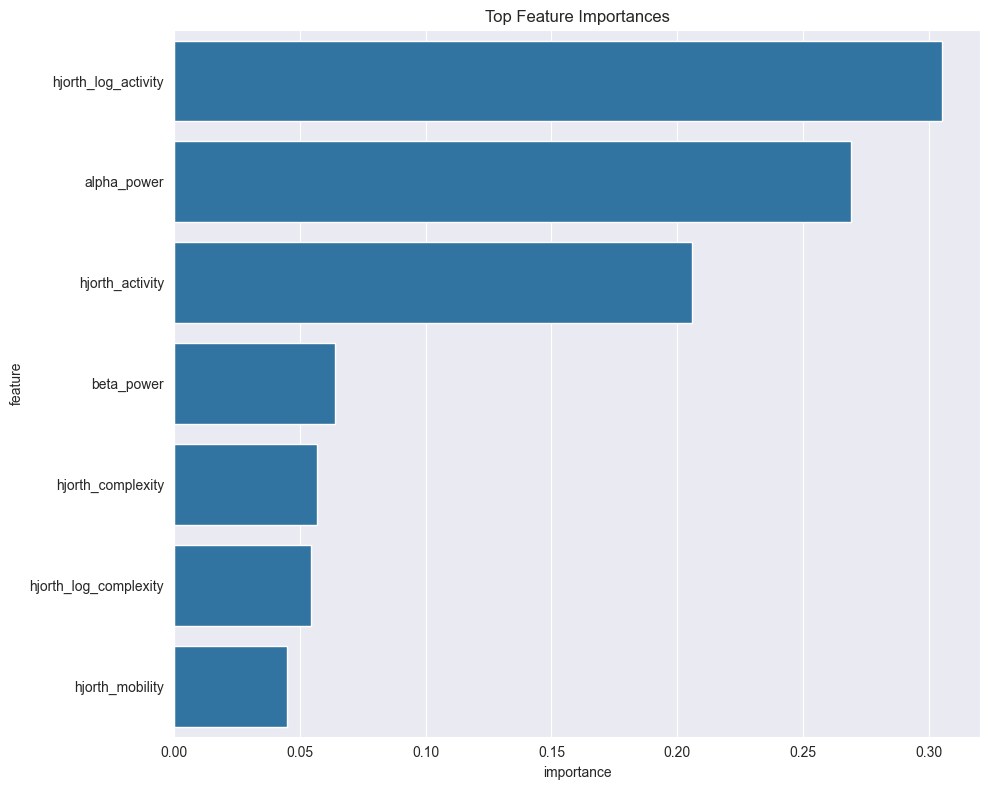


Grouped importance:
group
hjorth       0.666975
bandpower    0.333025
cfc          0.000000
lzc          0.000000
spectral     0.000000
Name: importance, dtype: float32


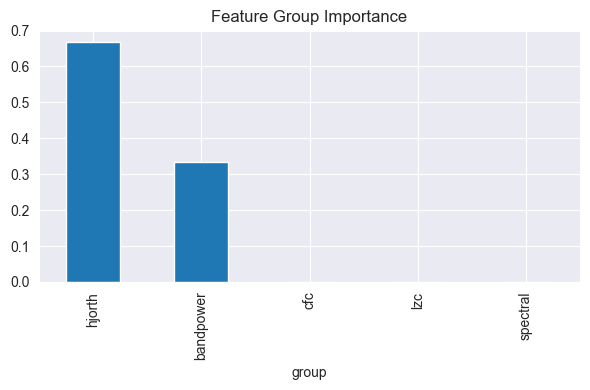

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# INDIVIDUAL FEATURE IMPORTANCE
# ============================================
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop features:")
print(importance_df.head(20)[importance_df["importance"]>0])


# Plot top features
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20)[importance_df["importance"]>0],
    x="importance",
    y="feature"
)
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()


# ============================================
# GROUPED IMPORTANCE (UPDATED)
# ============================================
def feature_group(name):
    # Hjorth (raw + log)
    if name.startswith("hjorth"):
        return "hjorth"

    # Spectral
    if name.startswith("spectral"):
        return "spectral"

    # Bandpower (normalized)
    if name.endswith("_power"):
        return "bandpower"

    # CFC
    if name.startswith("cfc"):
        return "cfc"

    # LZC
    if name == "lzc":
        return "lzc"

    return "other"


importance_df["group"] = importance_df["feature"].apply(feature_group)

grouped = (
    importance_df
    .groupby("group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\nGrouped importance:")
print(grouped)


# Plot grouped importance
plt.figure(figsize=(6, 4))
grouped.plot(kind="bar")
plt.title("Feature Group Importance")
plt.tight_layout()
plt.show()

# template multiple

In [18]:
import numpy as np

TARGET_SFREQ = 125
WINDOW_SEC = 0.25
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

# Toggle features here
FEATURE_SET = [
    "hjorth",
    "spectral",
    "bandpower",
    "coherence",   # connectivity
]

In [19]:
import mne

def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()  # (channels, samples)

        if not np.all(np.isfinite(data)):
            return None, None

        if np.any(np.std(data, axis=1) < 1e-10):
            return None, None

        return data, raw.ch_names

    except:
        return None, None

In [20]:
from scipy.signal import welch, coherence
from scipy.stats import entropy
from itertools import combinations

def hjorth_activity(x):
    return np.var(x)

def hjorth_mobility(x):
    if len(x) < 2:
        return np.nan
    v = np.var(x)
    if v == 0:
        return np.nan
    return np.sqrt(np.var(np.diff(x)) / v)

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    if np.isnan(m) or m == 0:
        return np.nan
    return hjorth_mobility(np.diff(x)) / m

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    return entropy(p)

def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

## feature extraction

In [21]:
def extract_features_window(data, ch_names):
    feats = {}
    n_channels = len(ch_names)

    # ============================================
    # PER-CHANNEL FEATURES
    # ============================================
    for i, ch in enumerate(ch_names):
        x = data[i]

        freqs, psd = welch(x, fs=TARGET_SFREQ, nperseg=min(len(x), TARGET_SFREQ*2))

        # Hjorth
        if "hjorth" in FEATURE_SET:
            a = hjorth_activity(x)
            m = hjorth_mobility(x)
            c = hjorth_complexity(x)

            feats[f"{ch}_hjorth_activity"] = a
            feats[f"{ch}_hjorth_mobility"] = m
            feats[f"{ch}_hjorth_complexity"] = c

            feats[f"{ch}_hjorth_log_activity"] = np.log1p(a) if a > 0 else np.nan
            feats[f"{ch}_hjorth_log_mobility"] = np.log1p(m) if m > 0 else np.nan
            feats[f"{ch}_hjorth_log_complexity"] = np.log1p(c) if c > 0 else np.nan

        # Spectral
        if "spectral" in FEATURE_SET:
            feats[f"{ch}_spectral_entropy"] = spectral_entropy(psd)
            feats[f"{ch}_spectral_complexity"] = spectral_complexity(psd)

        # Bandpower
        if "bandpower" in FEATURE_SET:
            total = 0
            bp = {}

            for b, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs < high)
                val = np.trapz(psd[mask], freqs[mask]) if np.any(mask) else 0
                bp[b] = val
                total += val

            for b in bp:
                feats[f"{ch}_{b}_power"] = bp[b] / total if total > 0 else np.nan

    # ============================================
    # COHERENCE (connectivity)
    # ============================================
    if "coherence" in FEATURE_SET:
        max_ch = min(8, n_channels)  # limit explosion

        for i, j in combinations(range(max_ch), 2):
            x = data[i]
            y = data[j]

            freqs, coh = coherence(x, y, fs=TARGET_SFREQ,
                                   nperseg=min(len(x), TARGET_SFREQ*2))

            for b, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs <= high)
                if np.any(mask):
                    feats[f"coh_{ch_names[i]}_{ch_names[j]}_{b}"] = np.mean(coh[mask])

    return feats

## dataset construction

In [22]:
all_data = []
feature_names = None

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:

    # -------- REST --------
    for f in rest_files[subj]:
        data, ch_names = load_signal_all_channels(f)
        if data is None:
            continue

        for i in range(data.shape[1] // WINDOW_LEN):
            w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

            if np.any(np.std(w, axis=1) < 1e-10):
                continue

            feats = extract_features_window(w, ch_names)

            vals = np.array(list(feats.values()))
            if not np.all(np.isfinite(vals)):
                continue

            if feature_names is None:
                feature_names = list(feats.keys())

            all_data.append((vals, 0, subj))

    # -------- TASK --------
    for f in task_files[subj]:
        data, ch_names = load_signal_all_channels(f)
        if data is None:
            continue

        for i in range(data.shape[1] // WINDOW_LEN):
            w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

            if np.any(np.std(w, axis=1) < 1e-10):
                continue

            feats = extract_features_window(w, ch_names)

            vals = np.array(list(feats.values()))
            if not np.all(np.isfinite(vals)):
                continue

            all_data.append((vals, 1, subj))

X_all = np.array([d[0] for d in all_data])
y_all = np.array([d[1] for d in all_data])
subjects_all = np.array([d[2] for d in all_data])

print("Total windows:", len(X_all))
print("Features:", X_all.shape[1])

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_76387/2427551622.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.trapz(psd[mask], freqs[mask]) if np.any(mask) else 0


Total windows: 60450
Features: 905


## split subjects

In [23]:
unique_subjects = np.unique(subjects_all)

np.random.seed(42)
train_subjects = np.random.choice(unique_subjects, int(0.7*len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects_all, train_subjects)
test_mask = np.isin(subjects_all, test_subjects)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

## model and results

In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.75      0.25      0.37      7254
           1       0.65      0.95      0.77     10881

    accuracy                           0.67     18135
   macro avg       0.70      0.60      0.57     18135
weighted avg       0.69      0.67      0.61     18135

ROC-AUC: 0.6663621783311031


## feature importance

                      feature  importance
380    Oz_hjorth_log_activity    0.034118
604       T8_spectral_entropy    0.030888
377        Oz_hjorth_activity    0.026307
602    T8_hjorth_log_mobility    0.020872
390        O1_hjorth_activity    0.019320
393    O1_hjorth_log_activity    0.015969
599        T8_hjorth_mobility    0.014925
407   Fpz_hjorth_log_mobility    0.012119
395  O1_hjorth_log_complexity    0.011143
276   TP9_hjorth_log_activity    0.010475
394    O1_hjorth_log_mobility    0.010426
1         Fp1_hjorth_mobility    0.010075
677      TP10_hjorth_mobility    0.009829
404       Fpz_hjorth_mobility    0.009611
550   FT8_hjorth_log_mobility    0.009061
547       FT8_hjorth_mobility    0.009026
768       PO8_hjorth_mobility    0.008611
378        Oz_hjorth_mobility    0.008462
601    T8_hjorth_log_activity    0.008437
680  TP10_hjorth_log_mobility    0.008349


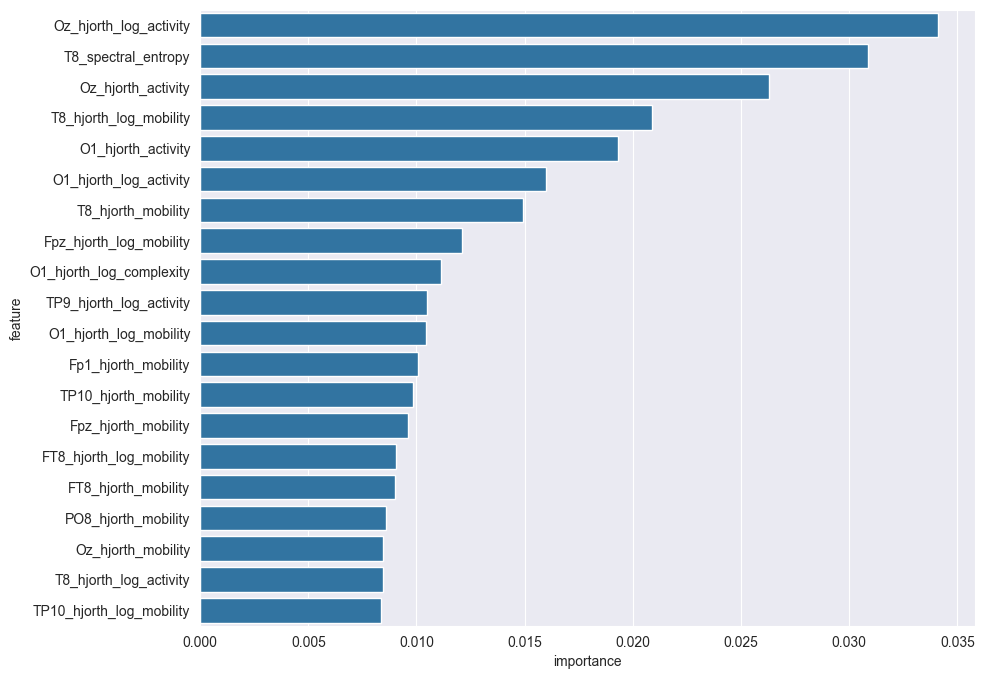

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.head(20))

plt.figure(figsize=(10,8))
sns.barplot(data=importance_df.head(20), x="importance", y="feature")
plt.show()

## try out stumps

In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=100,
    max_depth=1,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.76      0.22      0.34      7254
           1       0.65      0.95      0.77     10881

    accuracy                           0.66     18135
   macro avg       0.70      0.59      0.56     18135
weighted avg       0.69      0.66      0.60     18135

ROC-AUC: 0.6646513120471871



Grouped feature importance:
group
hjorth       0.813194
bandpower    0.127485
spectral     0.059321
coherence    0.000000
Name: importance, dtype: float32


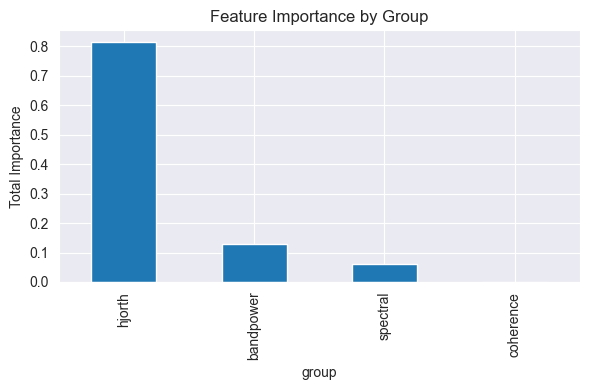

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# GROUPING FUNCTION (multi-channel aware)
# ============================================
def feature_group(name):
    # Coherence (connectivity)
    if name.startswith("coh_"):
        return "coherence"

    # Bandpower
    if name.endswith("_power"):
        return "bandpower"

    # Spectral
    if "spectral_" in name:
        return "spectral"

    # Hjorth (raw + log)
    if "hjorth" in name:
        return "hjorth"

    return "other"


# ============================================
# APPLY GROUPING
# ============================================
importance_df["group"] = importance_df["feature"].apply(feature_group)

grouped = (
    importance_df
    .groupby("group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\nGrouped feature importance:")
print(grouped)


# ============================================
# PLOT
# ============================================
plt.figure(figsize=(6, 4))
grouped.plot(kind="bar")
plt.title("Feature Importance by Group")
plt.ylabel("Total Importance")
plt.tight_layout()
plt.show()


Coherence importance by band:
band
alpha    0.0
beta     0.0
gamma    0.0
theta    0.0
Name: importance, dtype: float32


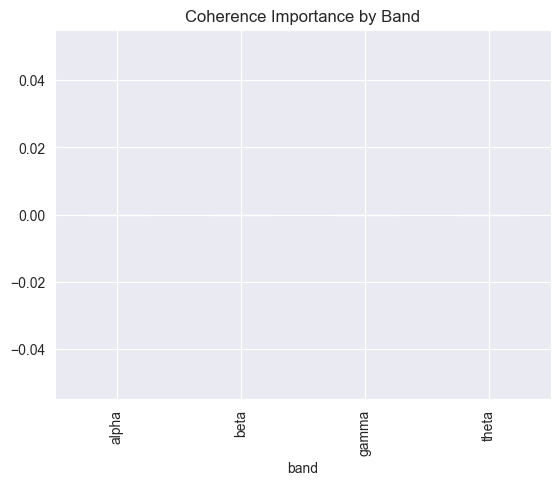

In [28]:
def coh_band(name):
    if name.startswith("coh_"):
        return name.split("_")[-1]
    return None

coh_df = importance_df[importance_df["feature"].str.startswith("coh_")].copy()
coh_df["band"] = coh_df["feature"].apply(coh_band)

coh_band_importance = (
    coh_df.groupby("band")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\nCoherence importance by band:")
print(coh_band_importance)

coh_band_importance.plot(kind="bar", title="Coherence Importance by Band")
plt.show()


Top channels:
channel
Oz      0.090974
T8      0.090945
O1      0.081110
Fpz     0.052778
FT8     0.037067
PO7     0.034988
O2      0.034275
TP10    0.031734
T7      0.029447
Fp2     0.029224
PO4     0.026333
TP9     0.025951
AF7     0.023665
PO3     0.022021
FC6     0.020728
Name: importance, dtype: float32


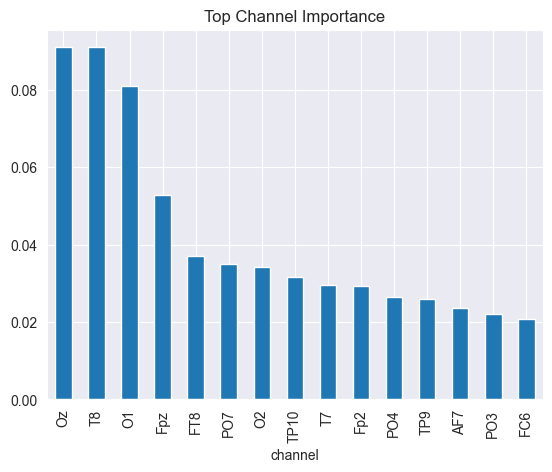

In [29]:
def extract_channel(name):
    # channel is always first token before "_"
    return name.split("_")[0]

ch_df = importance_df[~importance_df["feature"].str.startswith("coh_")].copy()
ch_df["channel"] = ch_df["feature"].apply(extract_channel)

channel_importance = (
    ch_df.groupby("channel")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop channels:")
print(channel_importance.head(15))

channel_importance.head(15).plot(kind="bar", title="Top Channel Importance")
plt.show()

# Individual Tangent Space Alignment - combined

In [31]:
import numpy as np
from scipy.linalg import fractional_matrix_power, eigvalsh
import mne

TARGET_SFREQ = 125
WINDOW_SEC = 0.25
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

FEATURE_SET = [
    "hjorth",
    "spectral",
    "bandpower",
    "coherence",
]

# ============================================
# RIEMANNIAN GEOMETRY FUNCTIONS
# ============================================

def compute_covariance(eeg_window):
    """
    Compute covariance matrix for an EEG window.
    eeg_window: (n_channels, n_samples)
    Returns: (n_channels, n_channels) covariance matrix
    """
    # Regularize to ensure positive definiteness
    cov = np.cov(eeg_window)
    # Add small regularization term
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def geometric_mean(cov_matrices, max_iter=50, tol=1e-6):
    """
    Compute Riemannian geometric mean (Karcher mean) of covariance matrices.
    """
    if len(cov_matrices) == 1:
        return cov_matrices[0]

    # Initialize with Euclidean mean
    mean = np.mean(cov_matrices, axis=0)

    # Strong regularization for numerical stability
    reg = 1e-6 * np.trace(mean) / len(mean) * np.eye(mean.shape[0])
    mean = mean + reg

    for _ in range(max_iter):
        # Compute inverse square root of current mean
        try:
            # Use eigendecomposition instead of fractional_matrix_power
            evals, evecs = np.linalg.eigh(mean)
            evals = np.maximum(evals, 1e-8)  # Clamp small eigenvalues
            mean_inv_sqrt = evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.T
        except:
            # If still fails, add more regularization
            mean += 1e-5 * np.eye(mean.shape[0])
            evals, evecs = np.linalg.eigh(mean)
            evals = np.maximum(evals, 1e-8)
            mean_inv_sqrt = evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.T

        # Map all matrices to tangent space
        tangent_vectors = []
        for C in cov_matrices:
            # Regularize each covariance matrix
            C_reg = C + 1e-8 * np.eye(C.shape[0])

            # Align to mean
            C_aligned = mean_inv_sqrt @ C_reg @ mean_inv_sqrt

            # Log map
            evals, evecs = np.linalg.eigh(C_aligned)
            evals = np.maximum(evals, 1e-8)
            log_C = evecs @ np.diag(np.log(evals)) @ evecs.T
            tangent_vectors.append(log_C)

        # Mean in tangent space
        tangent_mean = np.mean(tangent_vectors, axis=0)

        # Map back to manifold
        evals, evecs = np.linalg.eigh(tangent_mean)
        exp_tangent = evecs @ np.diag(np.exp(evals)) @ evecs.T

        # Update mean
        new_mean = mean_inv_sqrt @ exp_tangent @ mean_inv_sqrt

        # Check convergence
        diff = np.linalg.norm(new_mean - mean, 'fro') / (np.linalg.norm(mean, 'fro') + 1e-10)
        mean = new_mean

        if diff < tol:
            break

    return mean

def tangent_space_projection(cov_matrix, reference_matrix):
    """
    Project a covariance matrix to tangent space at reference_matrix.
    """
    # Regularize both matrices
    cov_matrix = cov_matrix + 1e-8 * np.eye(cov_matrix.shape[0])
    reference_matrix = reference_matrix + 1e-8 * np.eye(reference_matrix.shape[0])

    # Compute reference^(-1/2) using eigendecomposition
    evals, evecs = np.linalg.eigh(reference_matrix)
    evals = np.maximum(evals, 1e-8)
    ref_inv_sqrt = evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.T

    # Align to reference
    aligned = ref_inv_sqrt @ cov_matrix @ ref_inv_sqrt

    # Log map
    evals, evecs = np.linalg.eigh(aligned)
    evals = np.maximum(evals, 1e-8)
    log_aligned = evecs @ np.diag(np.log(evals)) @ evecs.T

    # Extract upper triangle (including diagonal)
    n = log_aligned.shape[0]
    tangent_vec = []
    for i in range(n):
        for j in range(i, n):
            if i == j:
                tangent_vec.append(log_aligned[i, j])
            else:
                tangent_vec.append(log_aligned[i, j] * np.sqrt(2))

    return np.array(tangent_vec)

# ============================================
# MODIFIED FEATURE EXTRACTION WITH ALIGNMENT
# ============================================

def load_and_process_signal(file_path):
    """Load EEG, preprocess, and return data and channel names"""
    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        if np.any(np.std(data, axis=1) < 1e-10):
            return None, None

        return data, raw.ch_names

    except Exception as e:
        return None, None

def extract_features_with_alignment(eeg_window, ch_names, subject_ref_cov=None):
    """
    Extract features with optional Riemannian pre-alignment.

    Args:
        eeg_window: (n_channels, n_samples) EEG window
        ch_names: List of channel names
        subject_ref_cov: Subject's reference covariance matrix (if None, skip alignment)

    Returns:
        feature vector (concatenated traditional features + Riemannian features)
    """
    # Compute covariance matrix for this window
    cov_window = compute_covariance(eeg_window)

    # If we have a subject reference, apply ITSA projection
    if subject_ref_cov is not None:
        tangent_features = tangent_space_projection(cov_window, subject_ref_cov)
    else:
        tangent_features = None

    # Extract traditional features
    traditional_features = extract_traditional_features(eeg_window, ch_names)

    # Combine features
    if tangent_features is not None:
        return np.concatenate([tangent_features, traditional_features])
    else:
        return traditional_features

def extract_traditional_features(eeg_window, ch_names):
    """Your original per-window feature extraction"""
    from scipy.signal import welch, coherence
    from scipy.stats import entropy
    from itertools import combinations

    feats = []
    n_channels = len(ch_names)

    # Per-channel features
    for i, ch in enumerate(ch_names):
        x = eeg_window[i]

        freqs, psd = welch(x, fs=TARGET_SFREQ, nperseg=min(len(x), TARGET_SFREQ*2))

        # Hjorth
        if "hjorth" in FEATURE_SET:
            a = np.var(x)
            m = np.sqrt(np.var(np.diff(x)) / a) if len(x) > 1 and a > 0 else np.nan
            c = (np.sqrt(np.var(np.diff(np.diff(x))) / np.var(np.diff(x))) / m) if m > 0 and not np.isnan(m) and len(x) > 2 else np.nan

            feats.extend([np.log1p(a), np.log1p(m) if m > 0 else np.nan,
                         np.log1p(c) if c > 0 else np.nan])
        else:
            feats.extend([np.nan] * 3)

        # Spectral entropy/complexity
        if "spectral" in FEATURE_SET:
            psd_norm = psd / (np.sum(psd) + 1e-12)
            spectral_entropy = entropy(psd_norm)
            uniform = np.ones_like(psd_norm) / len(psd_norm)
            spectral_complexity = entropy(psd_norm, uniform)
            feats.extend([spectral_entropy, spectral_complexity])
        else:
            feats.extend([np.nan] * 2)

        # Bandpower
        if "bandpower" in FEATURE_SET:
            total = 1e-12
            bp = {}
            for b, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs < high)
                val = np.trapz(psd[mask], freqs[mask]) if np.any(mask) else 0
                bp[b] = val
                total += val

            for b in bands.keys():
                feats.append(bp[b] / total if total > 0 else np.nan)

    # Coherence features
    if "coherence" in FEATURE_SET:
        max_ch = min(8, n_channels)
        for i, j in combinations(range(max_ch), 2):
            x = eeg_window[i]
            y = eeg_window[j]
            freqs, coh = coherence(x, y, fs=TARGET_SFREQ,
                                 nperseg=min(len(x), TARGET_SFREQ*2))

            for b, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs <= high)
                if np.any(mask):
                    feats.append(np.mean(coh[mask]))
                else:
                    feats.append(np.nan)

    # Replace any NaN/Inf with 0
    feats = np.array(feats)
    feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)

    return feats

# ============================================
# MAIN PIPELINE WITH ITSA
# ============================================

print("Loading data...")
all_covariances_per_subject = {}
all_windows_per_subject = {}
all_labels_per_subject = {}

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

# First pass: Collect windows and compute subject-specific reference covariances
for subj in valid_subjects:
    subject_covariances = []
    subject_windows = []
    subject_labels = []

    print(f"Processing subject {subj}...")

    # Collect rest windows
    for f in rest_files[subj]:
        data, ch_names = load_and_process_signal(f)
        if data is None:
            continue

        for i in range(data.shape[1] // WINDOW_LEN):
            w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]
            if np.any(np.std(w, axis=1) < 1e-10):
                continue

            subject_windows.append(w)
            subject_labels.append(0)

            # Store covariance for reference calculation
            cov = compute_covariance(w)
            subject_covariances.append(cov)

    # Collect task windows
    for f in task_files[subj]:
        data, ch_names = load_and_process_signal(f)
        if data is None:
            continue

        for i in range(data.shape[1] // WINDOW_LEN):
            w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]
            if np.any(np.std(w, axis=1) < 1e-10):
                continue

            subject_windows.append(w)
            subject_labels.append(1)

            # Store covariance for reference calculation
            cov = compute_covariance(w)
            subject_covariances.append(cov)

    if len(subject_covariances) > 0:
        # Compute subject-specific reference (geometric mean of all their windows)
        print(f"  Computing geometric mean for subject {subj} ({len(subject_covariances)} windows)...")
        subject_ref = geometric_mean(subject_covariances)

        all_covariances_per_subject[subj] = subject_ref
        all_windows_per_subject[subj] = (subject_windows, subject_labels, ch_names)
    else:
        print(f"  WARNING: No valid windows for subject {subj}")

# Second pass: Extract features using subject-specific alignment
print("\nExtracting features with ITSA alignment...")
all_data = []
all_labels = []
all_subjects = []

for subj in valid_subjects:
    print(f"Processing subject {subj}...")
    if subj not in all_windows_per_subject:
        continue

    windows, labels, ch_names = all_windows_per_subject[subj]
    subject_ref = all_covariances_per_subject[subj]

    print(f"  Extracting features for subject {subj} ({len(windows)} windows)")

    for i, (window, label) in enumerate(zip(windows, labels)):
        # Extract features with alignment to subject's reference
        features = extract_features_with_alignment(window, ch_names, subject_ref)

        all_data.append(features)
        all_labels.append(label)
        all_subjects.append(subj)

        if i % 100 == 0 and i > 0:
            print(f"    Processed {i}/{len(windows)} windows")

# Convert to arrays
X_all = np.array(all_data)
y_all = np.array(all_labels)
subjects_all = np.array(all_subjects)

print(f"\nTotal windows: {len(X_all)}")
print(f"Feature dimension: {X_all.shape[1]}")
print(f"Class distribution: {np.bincount(y_all)}")

# Train/test split by subject
unique_subjects = np.unique(subjects_all)
np.random.seed(42)
train_subjects = np.random.choice(unique_subjects, int(0.7 * len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

print(f"\nTrain subjects: {train_subjects}")
print(f"Test subjects: {test_subjects}")

train_mask = np.isin(subjects_all, train_subjects)
test_mask = np.isin(subjects_all, test_subjects)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Loading data...
Processing subject sub-13...
  Computing geometric mean for subject sub-13 (6045 windows)...
Processing subject sub-14...
  Computing geometric mean for subject sub-14 (6045 windows)...
Processing subject sub-15...
  Computing geometric mean for subject sub-15 (6045 windows)...
Processing subject sub-22...
  Computing geometric mean for subject sub-22 (6045 windows)...
Processing subject sub-23...
  Computing geometric mean for subject sub-23 (6045 windows)...
Processing subject sub-24...
  Computing geometric mean for subject sub-24 (6045 windows)...
Processing subject sub-25...
  Computing geometric mean for subject sub-25 (6045 windows)...
Processing subject sub-40...
  Computing geometric mean for subject sub-40 (6045 windows)...
Processing subject sub-47...
  Computing geometric mean for subject sub-47 (6045 windows)...
Processing subject sub-49...
  Computing geometric mean for subject sub-49 (6045 windows)...

Extracting features with ITSA alignment...
  Extracti

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_76387/1445521482.py:236: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.trapz(psd[mask], freqs[mask]) if np.any(mask) else 0


    Processed 100/6045 windows
    Processed 200/6045 windows
    Processed 300/6045 windows
    Processed 400/6045 windows
    Processed 500/6045 windows
    Processed 600/6045 windows
    Processed 700/6045 windows
    Processed 800/6045 windows
    Processed 900/6045 windows
    Processed 1000/6045 windows
    Processed 1100/6045 windows
    Processed 1200/6045 windows
    Processed 1300/6045 windows
    Processed 1400/6045 windows
    Processed 1500/6045 windows
    Processed 1600/6045 windows
    Processed 1700/6045 windows
    Processed 1800/6045 windows
    Processed 1900/6045 windows
    Processed 2000/6045 windows
    Processed 2100/6045 windows
    Processed 2200/6045 windows
    Processed 2300/6045 windows
    Processed 2400/6045 windows
    Processed 2500/6045 windows
    Processed 2600/6045 windows
    Processed 2700/6045 windows
    Processed 2800/6045 windows
    Processed 2900/6045 windows
    Processed 3000/6045 windows
    Processed 3100/6045 windows
    Processed 320


CLASSIFICATION RESULTS WITH ITSA
              precision    recall  f1-score   support

           0       0.78      0.24      0.37      7254
           1       0.65      0.96      0.78     10881

    accuracy                           0.67     18135
   macro avg       0.72      0.60      0.57     18135
weighted avg       0.70      0.67      0.61     18135

ROC-AUC: 0.6785

Top 20 most important features:
              feature  importance
1363  Riemannian_1363    0.025062
1395  Riemannian_1395    0.017032
2181  Traditional_290    0.015413
2352  Traditional_461    0.015344
1330  Riemannian_1330    0.012742
2191  Traditional_300    0.011469
1892    Traditional_1    0.010639
2212  Traditional_321    0.010331
92      Riemannian_92    0.008679
151    Riemannian_151    0.008653
2412  Traditional_521    0.008561
2202  Traditional_311    0.008252
2222  Traditional_331    0.007904
2353  Traditional_462    0.007902
2461  Traditional_570    0.007151
2360  Traditional_469    0.007091
2312  Tradit

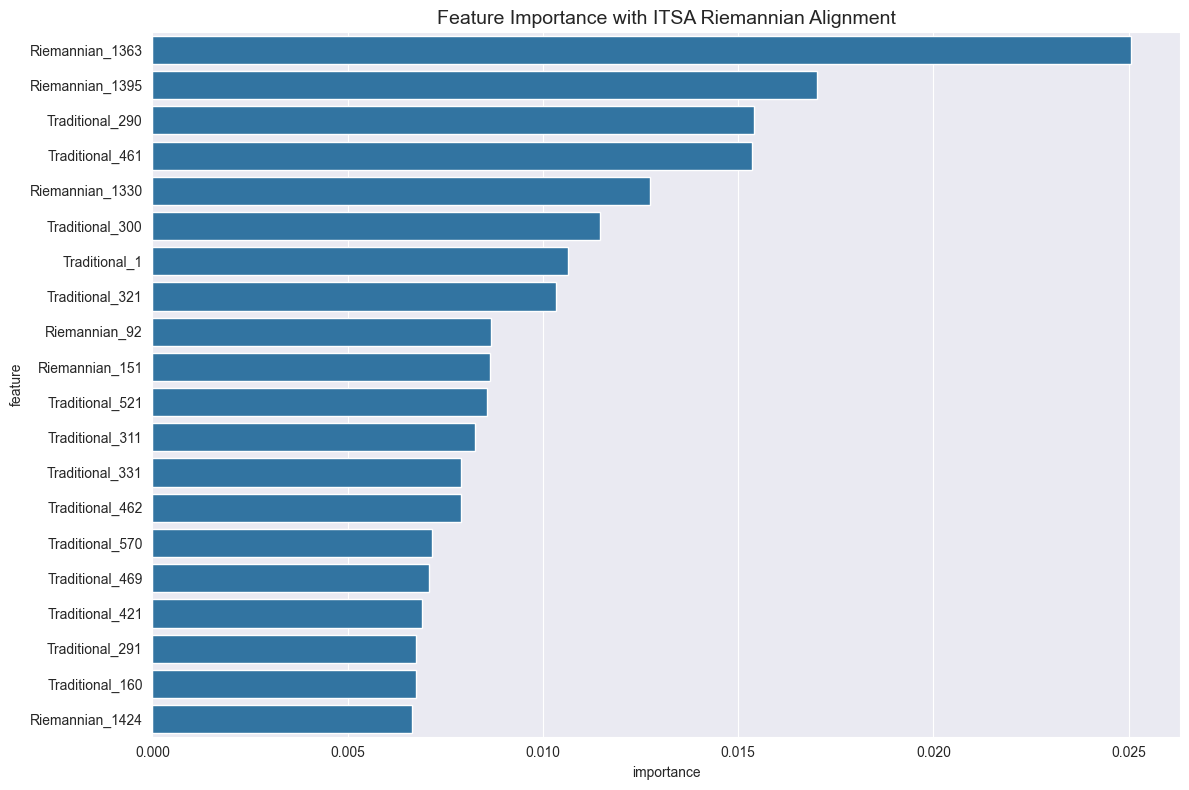

In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# IMPORTANT: Scale features after alignment
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*50)
print("CLASSIFICATION RESULTS WITH ITSA")
print("="*50)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# Feature importance visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Note: Features are now [Riemannian_tangent_features, traditional_features]
# The first (n_channels*(n_channels+1)//2) features are Riemannian
n_channels = len(ch_names)
n_riemannian_feats = n_channels * (n_channels + 1) // 2
riemannian_names = [f"Riemannian_{i}" for i in range(n_riemannian_feats)]
traditional_names = [f"Traditional_{i}" for i in range(X_all.shape[1] - n_riemannian_feats)]
all_feature_names = riemannian_names + traditional_names

importance_df = pd.DataFrame({
    "feature": all_feature_names[:len(model.feature_importances_)],
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 most important features:")
print(importance_df.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x="importance", y="feature")
plt.title("Feature Importance with ITSA Riemannian Alignment", fontsize=14)
plt.tight_layout()
plt.show()

# ITSA - only riemann alignment features

Loading data...
Processing subject sub-13...
  Computing geometric mean for subject sub-13 (6045 windows)...
Processing subject sub-14...
  Computing geometric mean for subject sub-14 (6045 windows)...
Processing subject sub-15...
  Computing geometric mean for subject sub-15 (6045 windows)...
Processing subject sub-22...
  Computing geometric mean for subject sub-22 (6045 windows)...
Processing subject sub-23...
  Computing geometric mean for subject sub-23 (6045 windows)...
Processing subject sub-24...
  Computing geometric mean for subject sub-24 (6045 windows)...
Processing subject sub-25...
  Computing geometric mean for subject sub-25 (6045 windows)...
Processing subject sub-40...
  Computing geometric mean for subject sub-40 (6045 windows)...
Processing subject sub-47...
  Computing geometric mean for subject sub-47 (6045 windows)...
Processing subject sub-49...
  Computing geometric mean for subject sub-49 (6045 windows)...

Extracting Riemannian tangent space features...
  Ext

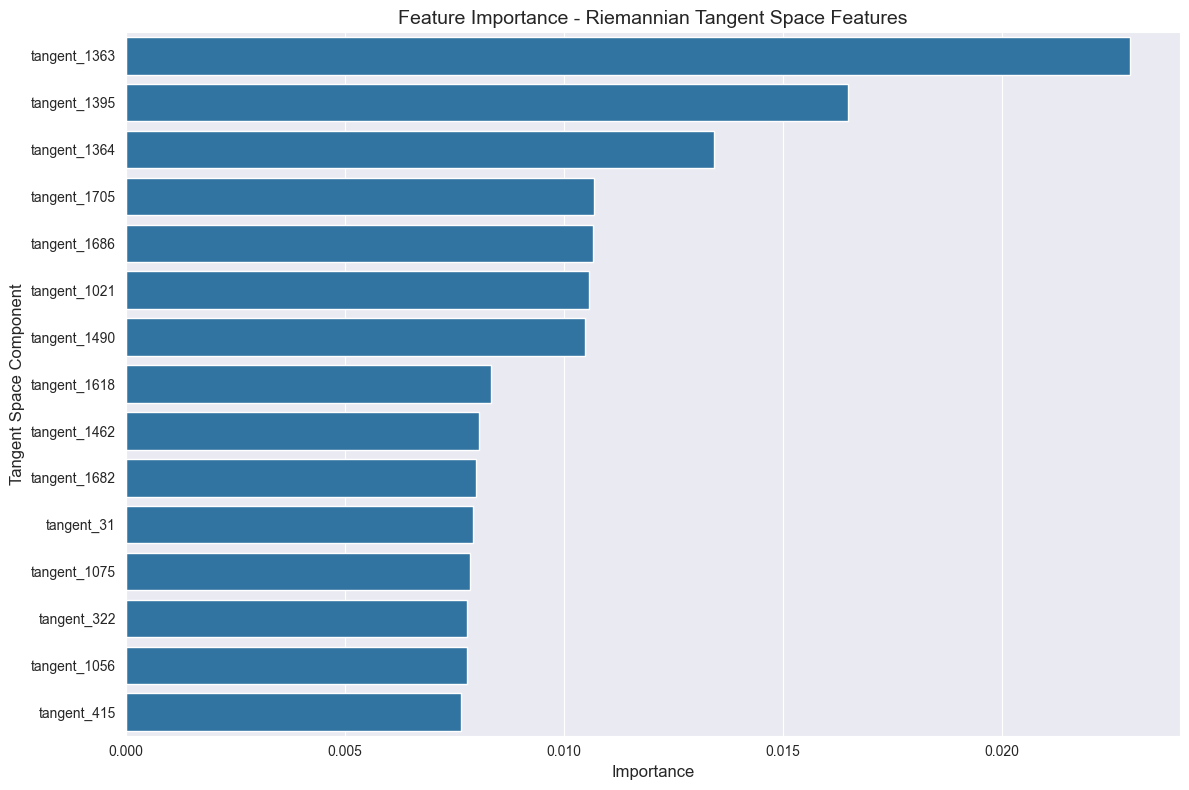


BASELINE COMPARISON
Your original pipeline (traditional features): ROC-AUC = 0.66
Riemannian + ITSA (this pipeline): ROC-AUC = 0.6548


In [33]:
import numpy as np
from scipy.linalg import eigh
import mne

TARGET_SFREQ = 125
WINDOW_SEC = 0.25
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

# ============================================
# RIEMANNIAN GEOMETRY FUNCTIONS
# ============================================

def compute_covariance(eeg_window, regularization=1e-6):
    """
    Compute regularized covariance matrix for an EEG window.
    """
    n_channels = eeg_window.shape[0]
    cov = np.cov(eeg_window)
    cov = (cov + cov.T) / 2  # Ensure symmetry
    cov += regularization * np.trace(cov) / n_channels * np.eye(n_channels)
    return cov

def geometric_mean(cov_matrices, max_iter=50, tol=1e-6):
    """
    Compute Riemannian geometric mean (Karcher mean) of covariance matrices.
    """
    if len(cov_matrices) == 1:
        return cov_matrices[0]

    # Initialize with Euclidean mean
    mean = np.mean(cov_matrices, axis=0)

    # Regularization
    reg = 1e-6 * np.trace(mean) / len(mean) * np.eye(mean.shape[0])
    mean = mean + reg

    for _ in range(max_iter):
        # Compute inverse square root using eigendecomposition
        evals, evecs = np.linalg.eigh(mean)
        evals = np.maximum(evals, 1e-8)
        mean_inv_sqrt = evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.T

        # Map all matrices to tangent space
        tangent_vectors = []
        for C in cov_matrices:
            C_reg = C + 1e-8 * np.eye(C.shape[0])
            C_aligned = mean_inv_sqrt @ C_reg @ mean_inv_sqrt

            evals, evecs = np.linalg.eigh(C_aligned)
            evals = np.maximum(evals, 1e-8)
            log_C = evecs @ np.diag(np.log(evals)) @ evecs.T
            tangent_vectors.append(log_C)

        # Mean in tangent space
        tangent_mean = np.mean(tangent_vectors, axis=0)

        # Map back to manifold
        evals, evecs = np.linalg.eigh(tangent_mean)
        exp_tangent = evecs @ np.diag(np.exp(evals)) @ evecs.T

        # Update mean
        new_mean = mean_inv_sqrt @ exp_tangent @ mean_inv_sqrt

        # Check convergence
        diff = np.linalg.norm(new_mean - mean, 'fro') / (np.linalg.norm(mean, 'fro') + 1e-10)
        mean = new_mean

        if diff < tol:
            break

    return mean

def tangent_space_projection(cov_matrix, reference_matrix):
    """
    Project a covariance matrix to tangent space at reference_matrix.
    Returns vectorized upper triangle of the tangent space matrix.
    """
    # Regularize both matrices
    cov_matrix = cov_matrix + 1e-8 * np.eye(cov_matrix.shape[0])
    reference_matrix = reference_matrix + 1e-8 * np.eye(reference_matrix.shape[0])

    # Compute reference^(-1/2)
    evals, evecs = np.linalg.eigh(reference_matrix)
    evals = np.maximum(evals, 1e-8)
    ref_inv_sqrt = evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.T

    # Align to reference
    aligned = ref_inv_sqrt @ cov_matrix @ ref_inv_sqrt

    # Log map
    evals, evecs = np.linalg.eigh(aligned)
    evals = np.maximum(evals, 1e-8)
    log_aligned = evecs @ np.diag(np.log(evals)) @ evecs.T

    # Vectorize upper triangle (including diagonal)
    n = log_aligned.shape[0]
    tangent_vec = []
    for i in range(n):
        for j in range(i, n):
            if i == j:
                tangent_vec.append(log_aligned[i, j])
            else:
                # Off-diagonals multiplied by sqrt(2) to preserve norm
                tangent_vec.append(log_aligned[i, j] * np.sqrt(2))

    return np.array(tangent_vec)

# ============================================
# DATA LOADING
# ============================================

def load_and_process_signal(file_path):
    """Load EEG, preprocess, and return data and channel names."""
    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        if np.any(np.std(data, axis=1) < 1e-10):
            return None, None

        return data, raw.ch_names

    except Exception:
        return None, None

# ============================================
# MAIN PIPELINE WITH ITSA (RIEMANNIAN ONLY)
# ============================================

print("Loading data...")
all_covariances_per_subject = {}
all_windows_per_subject = {}
all_labels_per_subject = {}

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

# First pass: Collect windows and compute subject-specific reference covariances
for subj in valid_subjects:
    subject_covariances = []
    subject_windows = []
    subject_labels = []

    print(f"Processing subject {subj}...")

    # Collect rest windows
    for f in rest_files[subj]:
        data, ch_names = load_and_process_signal(f)
        if data is None:
            continue

        for i in range(data.shape[1] // WINDOW_LEN):
            w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]
            if np.any(np.std(w, axis=1) < 1e-10):
                continue

            subject_windows.append(w)
            subject_labels.append(0)

            cov = compute_covariance(w)
            subject_covariances.append(cov)

    # Collect task windows
    for f in task_files[subj]:
        data, ch_names = load_and_process_signal(f)
        if data is None:
            continue

        for i in range(data.shape[1] // WINDOW_LEN):
            w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]
            if np.any(np.std(w, axis=1) < 1e-10):
                continue

            subject_windows.append(w)
            subject_labels.append(1)

            cov = compute_covariance(w)
            subject_covariances.append(cov)

    if len(subject_covariances) > 0:
        # Compute subject-specific reference (geometric mean)
        print(f"  Computing geometric mean for subject {subj} ({len(subject_covariances)} windows)...")
        subject_ref = geometric_mean(subject_covariances)

        all_covariances_per_subject[subj] = subject_ref
        all_windows_per_subject[subj] = (subject_windows, subject_labels, ch_names)
    else:
        print(f"  WARNING: No valid windows for subject {subj}")

# Second pass: Extract tangent space features using subject-specific alignment
print("\nExtracting Riemannian tangent space features...")
all_data = []
all_labels = []
all_subjects = []

for subj in valid_subjects:
    if subj not in all_windows_per_subject:
        continue

    windows, labels, ch_names = all_windows_per_subject[subj]
    subject_ref = all_covariances_per_subject[subj]

    print(f"  Extracting features for subject {subj} ({len(windows)} windows)")

    for i, (window, label) in enumerate(zip(windows, labels)):
        # Compute covariance for this window
        cov_window = compute_covariance(window)

        # Project to tangent space using subject's reference
        tangent_features = tangent_space_projection(cov_window, subject_ref)

        all_data.append(tangent_features)
        all_labels.append(label)
        all_subjects.append(subj)

        if i % 100 == 0 and i > 0:
            print(f"    Processed {i}/{len(windows)} windows")

# Convert to arrays
X_all = np.array(all_data)
y_all = np.array(all_labels)
subjects_all = np.array(all_subjects)

print(f"\n{'='*50}")
print("DATASET SUMMARY")
print(f"{'='*50}")
print(f"Total windows: {len(X_all)}")
print(f"Feature dimension: {X_all.shape[1]} (tangent space vector)")
print(f"Class distribution - Rest (0): {np.sum(y_all == 0)}, Task (1): {np.sum(y_all == 1)}")
print(f"Number of subjects: {len(np.unique(subjects_all))}")

# Train/test split by subject
unique_subjects = np.unique(subjects_all)
np.random.seed(42)
train_subjects = np.random.choice(unique_subjects, int(0.7 * len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

print(f"\nTrain subjects: {train_subjects}")
print(f"Test subjects: {test_subjects}")

train_mask = np.isin(subjects_all, train_subjects)
test_mask = np.isin(subjects_all, test_subjects)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# ============================================
# CLASSIFICATION
# ============================================

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Scale features (important for tangent space vectors)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"\n{'='*50}")
print("CLASSIFICATION RESULTS WITH ITSA (RIEMANNIAN ONLY)")
print(f"{'='*50}")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# ============================================
# FEATURE ANALYSIS
# ============================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create feature names for tangent space components
n_channels = len(ch_names)
n_features = n_channels * (n_channels + 1) // 2
feature_names = [f"tangent_{i}" for i in range(n_features)]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(f"\nTop 15 most important tangent space features:")
print(importance_df.head(15))

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Feature Importance - Riemannian Tangent Space Features", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Tangent Space Component", fontsize=12)
plt.tight_layout()
plt.show()

# Optional: Compare with your baseline
print(f"\n{'='*50}")
print("BASELINE COMPARISON")
print(f"{'='*50}")
print(f"Your original pipeline (traditional features): ROC-AUC = 0.66")
print(f"Riemannian + ITSA (this pipeline): ROC-AUC = {roc_auc_score(y_test, y_proba):.4f}")

## visualize


VISUALIZATION: Feature Space Before vs After ITSA
Extracting features BEFORE ITSA (raw covariance matrices)...
Collected 1000 samples before ITSA
  - Classes: rest=387, task=613

Creating visualization with 1000 samples...
Computing t-SNE for BEFORE data...
Computing t-SNE for AFTER data...


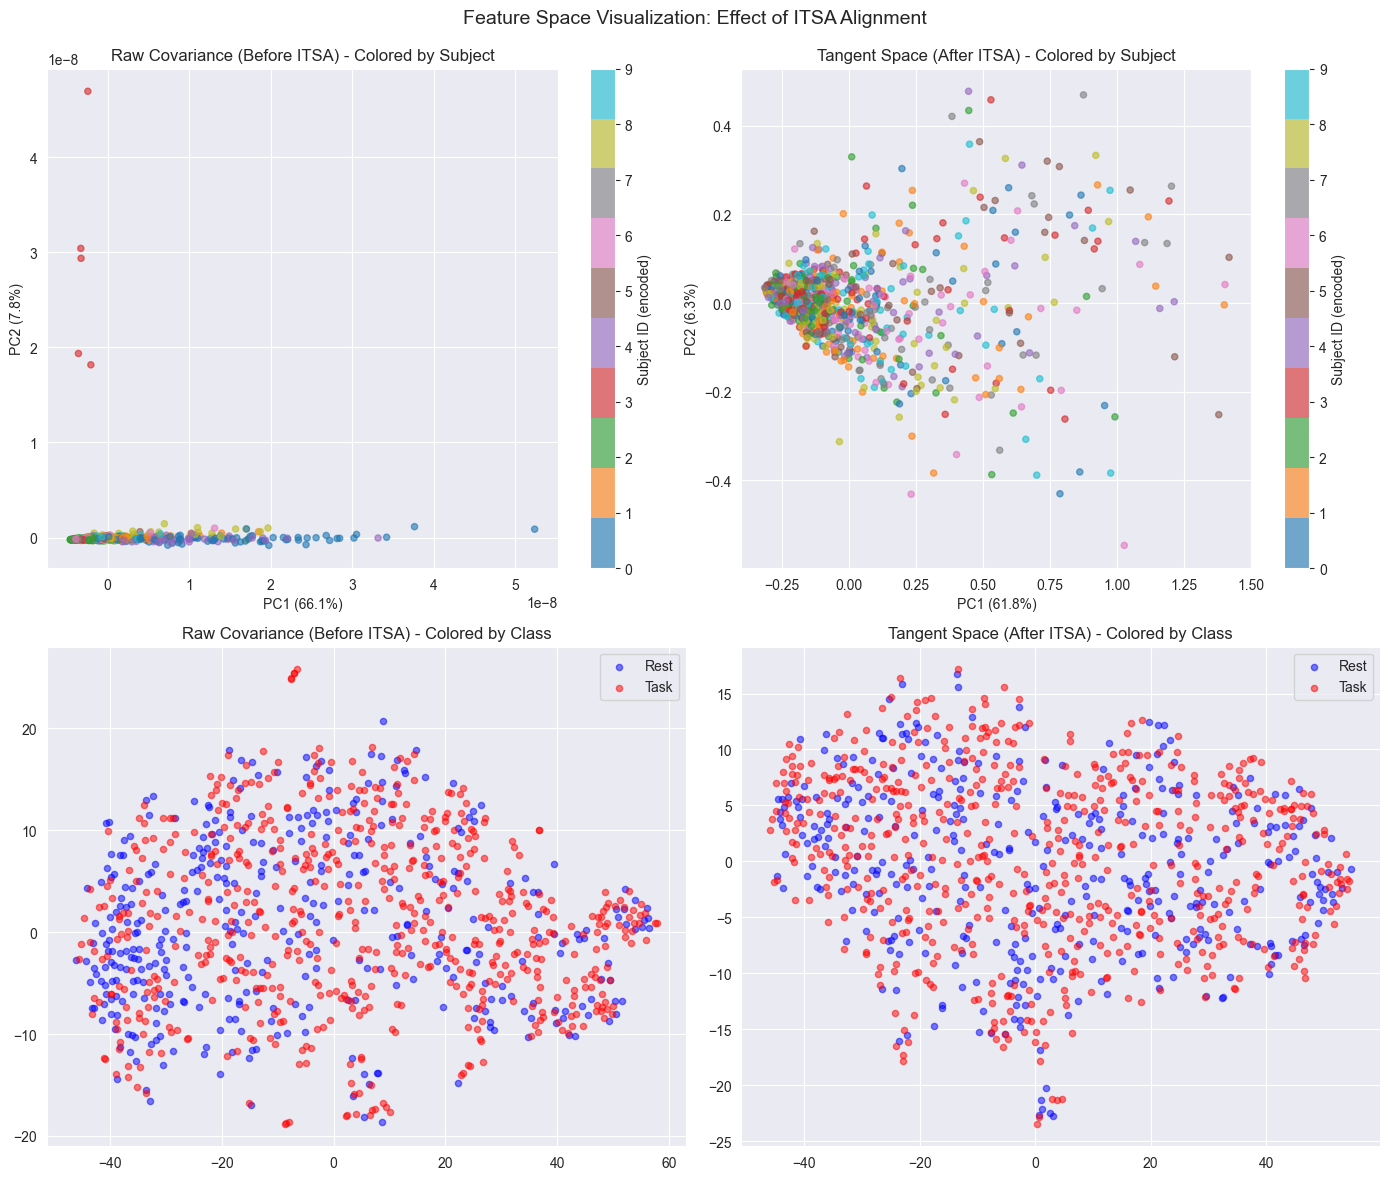


QUANTITATIVE COMPARISON

Average Within-Subject Distance:
  Before ITSA: 0.000
  After ITSA:  0.449
  Change: +7427786627.7%

Average Between-Subject Distance:
  Before ITSA: 0.000
  After ITSA:  0.449
  Change: +5833771753.7%

Separation Ratio (Between/Within):
  Before ITSA: 1.274
  After ITSA:  1.000
  Improvement: -21.5%

Visualizing subject alignment for 10 subjects...


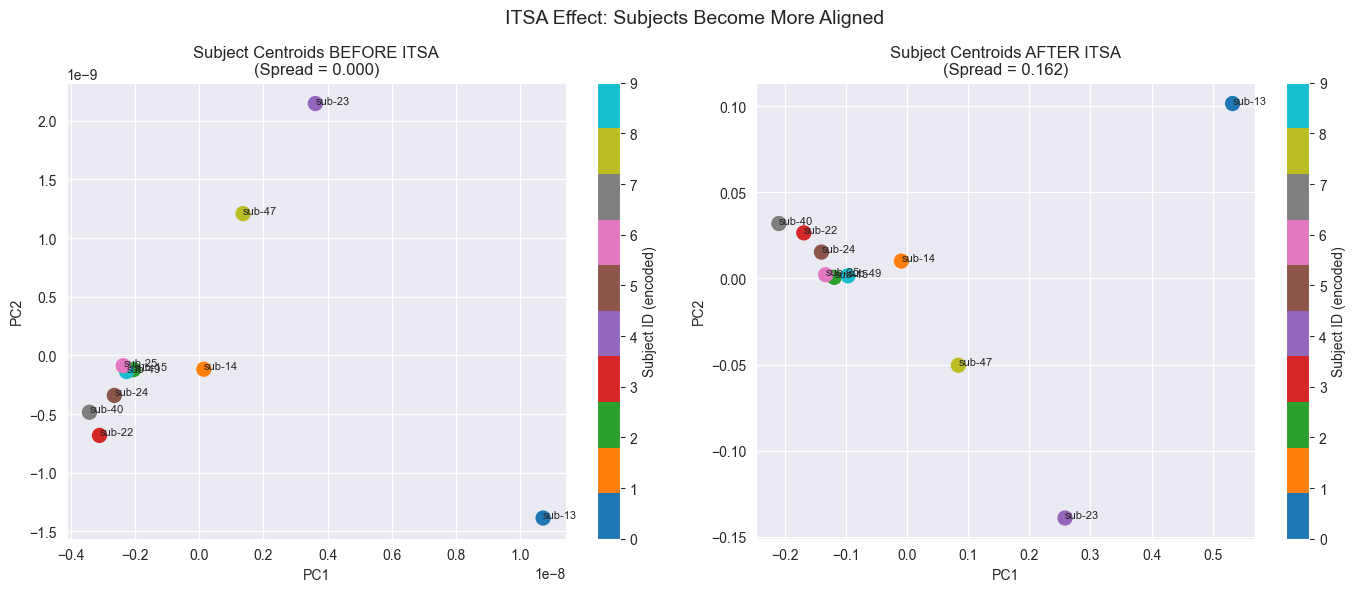


Subject Centroid Spread:
  Before ITSA: 0.000
  After ITSA:  0.162
  Reduction: -5374859715.5%


In [36]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns

def visualize_feature_spaces(X_before, X_after, y, subjects, before_name="Before ITSA", after_name="After ITSA"):
    """
    Visualize the effect of ITSA alignment on feature space.
    """
    # Convert string subject IDs to numeric codes
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    subject_codes = le.fit_transform(subjects)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # 1. PCA of features BEFORE ITSA
    pca_before = PCA(n_components=2, random_state=42)
    X_pca_before = pca_before.fit_transform(X_before)

    scatter1 = axes[0, 0].scatter(X_pca_before[:, 0], X_pca_before[:, 1],
                                   c=subject_codes, cmap='tab10', alpha=0.6, s=20)
    axes[0, 0].set_title(f'{before_name} - Colored by Subject', fontsize=12)
    axes[0, 0].set_xlabel(f'PC1 ({pca_before.explained_variance_ratio_[0]:.1%})')
    axes[0, 0].set_ylabel(f'PC2 ({pca_before.explained_variance_ratio_[1]:.1%})')
    plt.colorbar(scatter1, ax=axes[0, 0], label='Subject ID (encoded)')

    # 2. PCA of features AFTER ITSA
    pca_after = PCA(n_components=2, random_state=42)
    X_pca_after = pca_after.fit_transform(X_after)

    scatter2 = axes[0, 1].scatter(X_pca_after[:, 0], X_pca_after[:, 1],
                                   c=subject_codes, cmap='tab10', alpha=0.6, s=20)
    axes[0, 1].set_title(f'{after_name} - Colored by Subject', fontsize=12)
    axes[0, 1].set_xlabel(f'PC1 ({pca_after.explained_variance_ratio_[0]:.1%})')
    axes[0, 1].set_ylabel(f'PC2 ({pca_after.explained_variance_ratio_[1]:.1%})')
    plt.colorbar(scatter2, ax=axes[0, 1], label='Subject ID (encoded)')

    # 3. t-SNE colored by class (before)
    print("Computing t-SNE for BEFORE data...")
    tsne_before = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne_before = tsne_before.fit_transform(X_before)

    axes[1, 0].scatter(X_tsne_before[y==0, 0], X_tsne_before[y==0, 1],
                       c='blue', label='Rest', alpha=0.5, s=20)
    axes[1, 0].scatter(X_tsne_before[y==1, 0], X_tsne_before[y==1, 1],
                       c='red', label='Task', alpha=0.5, s=20)
    axes[1, 0].set_title(f'{before_name} - Colored by Class', fontsize=12)
    axes[1, 0].legend()

    # 4. t-SNE colored by class (after)
    print("Computing t-SNE for AFTER data...")
    tsne_after = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne_after = tsne_after.fit_transform(X_after)

    axes[1, 1].scatter(X_tsne_after[y==0, 0], X_tsne_after[y==0, 1],
                       c='blue', label='Rest', alpha=0.5, s=20)
    axes[1, 1].scatter(X_tsne_after[y==1, 0], X_tsne_after[y==1, 1],
                       c='red', label='Task', alpha=0.5, s=20)
    axes[1, 1].set_title(f'{after_name} - Colored by Class', fontsize=12)
    axes[1, 1].legend()

    plt.suptitle('Feature Space Visualization: Effect of ITSA Alignment', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Additional metrics
    print("\n" + "="*50)
    print("QUANTITATIVE COMPARISON")
    print("="*50)

    # Within-subject vs between-subject distances
    from sklearn.metrics import pairwise_distances

    # Calculate distances
    dist_before = pairwise_distances(X_before)
    dist_after = pairwise_distances(X_after)

    # Separate within-subject and between-subject distances
    n_samples = len(subjects)
    within_before, between_before = [], []
    within_after, between_after = [], []

    for i in range(n_samples):
        for j in range(i+1, n_samples):
            if subjects[i] == subjects[j]:
                within_before.append(dist_before[i, j])
                within_after.append(dist_after[i, j])
            else:
                between_before.append(dist_before[i, j])
                between_after.append(dist_after[i, j])

    print(f"\nAverage Within-Subject Distance:")
    print(f"  Before ITSA: {np.mean(within_before):.3f}")
    print(f"  After ITSA:  {np.mean(within_after):.3f}")
    print(f"  Change: {(np.mean(within_after)/np.mean(within_before)-1)*100:+.1f}%")

    print(f"\nAverage Between-Subject Distance:")
    print(f"  Before ITSA: {np.mean(between_before):.3f}")
    print(f"  After ITSA:  {np.mean(between_after):.3f}")
    print(f"  Change: {(np.mean(between_after)/np.mean(between_before)-1)*100:+.1f}%")

    sep_ratio_before = np.mean(between_before)/np.mean(within_before)
    sep_ratio_after = np.mean(between_after)/np.mean(within_after)

    print(f"\nSeparation Ratio (Between/Within):")
    print(f"  Before ITSA: {sep_ratio_before:.3f}")
    print(f"  After ITSA:  {sep_ratio_after:.3f}")
    print(f"  Improvement: {(sep_ratio_after/sep_ratio_before-1)*100:+.1f}%")


def visualize_subject_alignment(X_by_subject_before, X_by_subject_after, subject_ids):
    """
    Visualize how ITSA brings subjects' data closer together.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Calculate distances between subject centroids
    centroids_before = [np.mean(X, axis=0) for X in X_by_subject_before]
    centroids_after = [np.mean(X, axis=0) for X in X_by_subject_after]

    # PCA on centroids
    pca_before = PCA(n_components=2)
    centroids_pca_before = pca_before.fit_transform(centroids_before)

    pca_after = PCA(n_components=2)
    centroids_pca_after = pca_after.fit_transform(centroids_after)

    # Convert subject IDs to numeric for coloring
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    subject_codes = le.fit_transform(subject_ids)

    # Plot subject centroids
    scatter1 = axes[0].scatter(centroids_pca_before[:, 0], centroids_pca_before[:, 1],
                                c=subject_codes, cmap='tab10', s=100)
    for i, subj in enumerate(subject_ids):
        axes[0].annotate(subj, centroids_pca_before[i], fontsize=8)
    axes[0].set_title(f'Subject Centroids BEFORE ITSA\n(Spread = {np.std(centroids_pca_before):.3f})')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    plt.colorbar(scatter1, ax=axes[0], label='Subject ID (encoded)')

    scatter2 = axes[1].scatter(centroids_pca_after[:, 0], centroids_pca_after[:, 1],
                                c=subject_codes, cmap='tab10', s=100)
    for i, subj in enumerate(subject_ids):
        axes[1].annotate(subj, centroids_pca_after[i], fontsize=8)
    axes[1].set_title(f'Subject Centroids AFTER ITSA\n(Spread = {np.std(centroids_pca_after):.3f})')
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    plt.colorbar(scatter2, ax=axes[1], label='Subject ID (encoded)')

    plt.suptitle('ITSA Effect: Subjects Become More Aligned', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Print spread reduction
    spread_before = np.std(centroids_pca_before)
    spread_after = np.std(centroids_pca_after)
    print(f"\nSubject Centroid Spread:")
    print(f"  Before ITSA: {spread_before:.3f}")
    print(f"  After ITSA:  {spread_after:.3f}")
    print(f"  Reduction: {(1 - spread_after/spread_before)*100:.1f}%")

# ============================================
# FIXED VISUALIZATION CODE
# ============================================

# After collecting windows but BEFORE ITSA alignment
print("\n" + "="*50)
print("VISUALIZATION: Feature Space Before vs After ITSA")
print("="*50)

# Collect features BEFORE ITSA (raw covariance matrices)
print("Extracting features BEFORE ITSA (raw covariance matrices)...")
X_before_all = []
subject_ids_before = []
y_before_all = []  # Also store labels for before

for subj in valid_subjects:
    if subj not in all_windows_per_subject:
        continue

    windows, labels, ch_names = all_windows_per_subject[subj]

    # Sample up to 100 windows per subject, but don't exceed available windows
    n_samples = min(100, len(windows))
    sampled_indices = np.random.choice(len(windows), n_samples, replace=False)

    for idx in sampled_indices:
        window = windows[idx]
        label = labels[idx]
        cov = compute_covariance(window)

        # Flatten upper triangle (same as tangent space but without projection)
        n = cov.shape[0]
        flat_cov = []
        for i in range(n):
            for j in range(i, n):
                if i == j:
                    flat_cov.append(cov[i, j])
                else:
                    flat_cov.append(cov[i, j] * np.sqrt(2))
        X_before_all.append(flat_cov)
        subject_ids_before.append(subj)
        y_before_all.append(label)

X_before_all = np.array(X_before_all)
y_before_all = np.array(y_before_all)
subject_ids_before = np.array(subject_ids_before)

print(f"Collected {len(X_before_all)} samples before ITSA")
print(f"  - Classes: rest={np.sum(y_before_all==0)}, task={np.sum(y_before_all==1)}")

# Now run your ITSA pipeline to get X_after_all (tangent space features)
# ... (your complete ITSA pipeline from earlier goes here) ...

# After ITSA pipeline completes, subsample BOTH to the SAME size
# Use the smaller of the two datasets
n_vis_samples = min(len(X_before_all), len(X_all), 2000)  # Max 2000 points for visualization

print(f"\nCreating visualization with {n_vis_samples} samples...")

# Randomly sample from AFTER-ITSA data
indices_after = np.random.choice(len(X_all), n_vis_samples, replace=False)
X_after_sample = X_all[indices_after]
y_after_sample = y_all[indices_after]
subjects_after_sample = subjects_all[indices_after]

# Randomly sample from BEFORE-ITSA data (same size)
indices_before = np.random.choice(len(X_before_all), n_vis_samples, replace=False)
X_before_sample = X_before_all[indices_before]
y_before_sample = y_before_all[indices_before]
subjects_before_sample = subject_ids_before[indices_before]

# Visualize!
visualize_feature_spaces(
    X_before_sample,
    X_after_sample,
    y_before_sample,  # Use labels from before
    subjects_before_sample,  # Use subjects from before
    before_name="Raw Covariance (Before ITSA)",
    after_name="Tangent Space (After ITSA)"
)

# Optional: Visualize subject alignment if you have enough samples per subject
# Group by subject for centroid visualization
X_before_by_subject = []
X_after_by_subject = []
subject_list = []

# Get subjects that appear in BOTH datasets with enough samples
common_subjects = set(subjects_before_sample) & set(subjects_after_sample)

for subj in common_subjects:
    mask_before = subjects_before_sample == subj
    mask_after = subjects_after_sample == subj

    if np.sum(mask_before) > 5 and np.sum(mask_after) > 5:  # At least 5 samples per subject
        X_before_by_subject.append(X_before_sample[mask_before])
        X_after_by_subject.append(X_after_sample[mask_after])
        subject_list.append(subj)

if len(X_before_by_subject) >= 2:  # Need at least 2 subjects for visualization
    print(f"\nVisualizing subject alignment for {len(X_before_by_subject)} subjects...")
    visualize_subject_alignment(X_before_by_subject, X_after_by_subject, subject_list)
else:
    print(f"\nNot enough subjects with sufficient samples for centroid visualization (need at least 2, got {len(X_before_by_subject)})")

# another

In [39]:
import numpy as np
import mne

from scipy.signal import welch, coherence
from scipy.stats import entropy
from itertools import combinations
from scipy.linalg import fractional_matrix_power

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.covariance import LedoitWolf

from xgboost import XGBClassifier

from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace

# ============================================================
# CONFIG
# ============================================================

TARGET_SFREQ = 125
WINDOW_SEC = 0.25
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

FEATURE_SET = ["hjorth", "spectral", "bandpower", "coherence"]

# ============================================================
# SIGNAL LOADING
# ============================================================

def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        if np.any(np.std(data, axis=1) < 1e-10):
            return None, None

        return data, raw.ch_names
    except:
        return None, None

# ============================================================
# FEATURE FUNCTIONS (UNCHANGED)
# ============================================================

def hjorth_activity(x): return np.var(x)

def hjorth_mobility(x):
    if len(x) < 2: return np.nan
    v = np.var(x)
    if v == 0: return np.nan
    return np.sqrt(np.var(np.diff(x)) / v)

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    if np.isnan(m) or m == 0: return np.nan
    return hjorth_mobility(np.diff(x)) / m

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    return entropy(p)

def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

def extract_features_window(data, ch_names):
    feats = {}
    n_channels = len(ch_names)

    for i, ch in enumerate(ch_names):
        x = data[i]

        freqs, psd = welch(
            x,
            fs=TARGET_SFREQ,
            nperseg=WINDOW_LEN,
            noverlap=0
        )

        if "hjorth" in FEATURE_SET:
            a = hjorth_activity(x)
            m = hjorth_mobility(x)
            c = hjorth_complexity(x)

            feats[f"{ch}_a"] = a
            feats[f"{ch}_m"] = m
            feats[f"{ch}_c"] = c

        if "spectral" in FEATURE_SET:
            feats[f"{ch}_se"] = spectral_entropy(psd)

        if "bandpower" in FEATURE_SET:
            total = 0
            bp = {}

            for b, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs < high)
                val = np.trapezoid(psd[mask], freqs[mask]) if np.any(mask) else 0
                bp[b] = val
                total += val

            for b in bp:
                feats[f"{ch}_{b}"] = bp[b] / total if total > 0 else np.nan

    if "coherence" in FEATURE_SET:
        max_ch = min(8, n_channels)

        for i, j in combinations(range(max_ch), 2):
            freqs, coh = coherence(
                data[i], data[j],
                fs=TARGET_SFREQ,
                nperseg=WINDOW_LEN,
                noverlap=0
            )
            feats[f"coh_{i}_{j}"] = np.mean(coh)

    return feats

# ============================================================
# COVARIANCE (ITSA)
# ============================================================

def compute_covariance(w):
    # shrinkage covariance for stability
    return LedoitWolf().fit(w.T).covariance_

def whiten(C, C_ref):
    C_ref_inv_sqrt = fractional_matrix_power(C_ref, -0.5)
    return C_ref_inv_sqrt @ C @ C_ref_inv_sqrt

# ============================================================
# DATA BUILDING
# ============================================================

all_feats = []
all_covs = []
all_labels = []
all_subjects = []

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:

    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                continue

            for i in range(data.shape[1] // WINDOW_LEN):
                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                # handcrafted features
                feats = extract_features_window(w, ch_names)
                vals = np.array(list(feats.values()))
                if not np.all(np.isfinite(vals)):
                    continue

                # covariance
                C = compute_covariance(w)

                all_feats.append(vals)
                all_covs.append(C)
                all_labels.append(label)
                all_subjects.append(subj)

X_feats = np.array(all_feats)
covs = np.array(all_covs)
y = np.array(all_labels)
subjects = np.array(all_subjects)

# ============================================================
# SUBJECT SPLIT
# ============================================================

unique_subjects = np.unique(subjects)
np.random.seed(42)

train_subjects = np.random.choice(unique_subjects, int(0.7*len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

# ============================================================
# ITSA
# ============================================================

covs_train = covs[train_mask]
covs_test  = covs[test_mask]

subjects_train = subjects[train_mask]
subjects_test  = subjects[test_mask]

# ---- per-subject mean ----
C_ref = {}
for s in unique_subjects:
    idx = subjects == s
    C_ref[s] = mean_covariance(covs[idx], metric='riemann')

# ---- whitening ----
covs_white = []
for i in range(len(covs)):
    covs_white.append(whiten(covs[i], C_ref[subjects[i]]))
covs_white = np.array(covs_white)

covs_white_train = covs_white[train_mask]
covs_white_test  = covs_white[test_mask]

# ---- tangent space ----
ts = TangentSpace(metric='riemann')
ts.fit(covs_white_train)

X_ts_train = ts.transform(covs_white_train)
X_ts_test  = ts.transform(covs_white_test)

# ============================================================
# FINAL FEATURES
# ============================================================

X_train = np.concatenate([X_feats[train_mask], X_ts_train], axis=1)
X_test  = np.concatenate([X_feats[test_mask],  X_ts_test], axis=1)

y_train = y[train_mask]
y_test  = y[test_mask]

# ============================================================
# MODEL
# ============================================================

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.73      0.46      0.57      7254
           1       0.71      0.89      0.79     10881

    accuracy                           0.72     18135
   macro avg       0.72      0.67      0.68     18135
weighted avg       0.72      0.72      0.70     18135

ROC-AUC: 0.7513083363403987


## now exact model

In [40]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.73      0.44      0.55      7254
           1       0.70      0.89      0.79     10881

    accuracy                           0.71     18135
   macro avg       0.72      0.66      0.67     18135
weighted avg       0.71      0.71      0.69     18135

ROC-AUC: 0.7500788032307906


## feature importances

In [41]:
# handcrafted feature names
feat_names_hand = list(feats.keys())  # or your stored feature_names

# ITSA feature names
n_ts = X_ts_train.shape[1]
feat_names_ts = [f"ts_{i}" for i in range(n_ts)]

# combined
feature_names_full = feat_names_hand + feat_names_ts

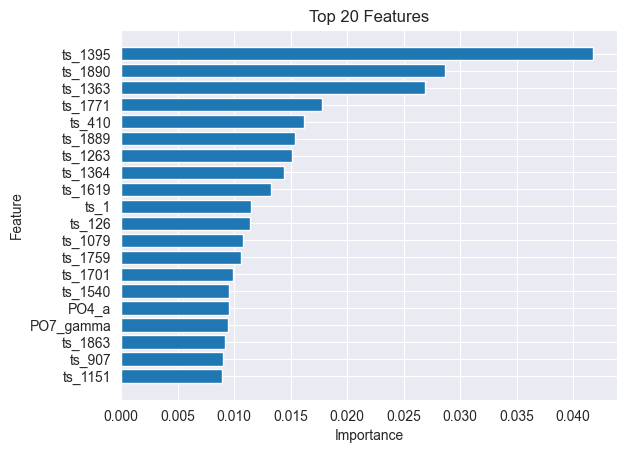

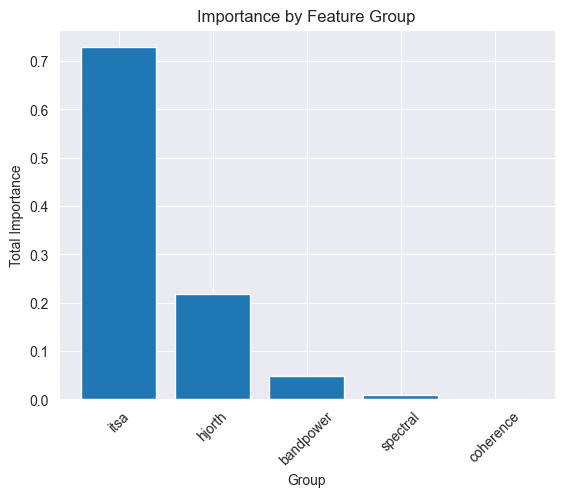

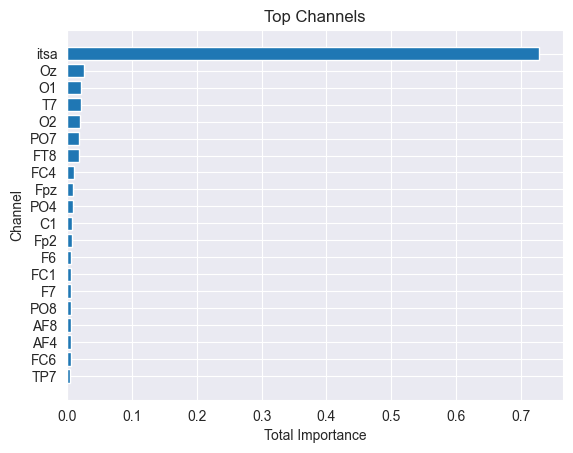

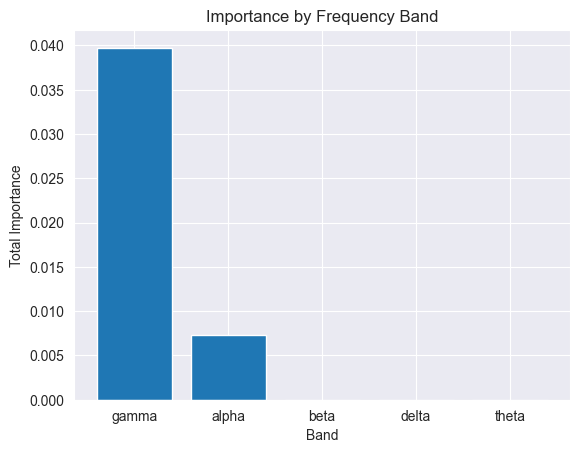


Top 20 features:
        feature  importance      group
1972    ts_1395    0.041793       itsa
2467    ts_1890    0.028680       itsa
1940    ts_1363    0.026927       itsa
2348    ts_1771    0.017784       itsa
987      ts_410    0.016228       itsa
2466    ts_1889    0.015354       itsa
1840    ts_1263    0.015124       itsa
1941    ts_1364    0.014435       itsa
2196    ts_1619    0.013233       itsa
578        ts_1    0.011522       itsa
703      ts_126    0.011419       itsa
1656    ts_1079    0.010752       itsa
2336    ts_1759    0.010648       itsa
2278    ts_1701    0.009937       itsa
2117    ts_1540    0.009583       itsa
522       PO4_a    0.009535     hjorth
260   PO7_gamma    0.009439  bandpower
2440    ts_1863    0.009231       itsa
1484     ts_907    0.009030       itsa
1728    ts_1151    0.008908       itsa

Group importance:
group
itsa         0.728354
hjorth       0.216681
bandpower    0.047027
spectral     0.007938
coherence    0.000000
Name: importance, dtype: flo

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import re

importance_df = pd.DataFrame({
    "feature": feature_names_full,
    "importance": model.feature_importances_
})

# --------------------------------------------------
# GROUPING LOGIC
# --------------------------------------------------

def categorize(feat):
    if feat.startswith("ts_"):
        return "itsa"
    if feat.startswith("coh_"):
        return "coherence"
    if feat.endswith("_a") or feat.endswith("_m") or feat.endswith("_c"):
        return "hjorth"
    if feat.endswith("_se"):
        return "spectral"
    if any(b in feat for b in ["delta", "theta", "alpha", "beta", "gamma"]):
        return "bandpower"
    return "other"

importance_df["group"] = importance_df["feature"].apply(categorize)

# --------------------------------------------------
# TOP FEATURES
# --------------------------------------------------

top_df = importance_df.sort_values("importance", ascending=False).head(20)

plt.figure()
plt.barh(top_df["feature"], top_df["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# --------------------------------------------------
# GROUP IMPORTANCE
# --------------------------------------------------

group_df = importance_df.groupby("group")["importance"].sum().sort_values(ascending=False)

plt.figure()
plt.bar(group_df.index, group_df.values)
plt.title("Importance by Feature Group")
plt.xlabel("Group")
plt.ylabel("Total Importance")
plt.xticks(rotation=45)
plt.show()

# --------------------------------------------------
# CHANNEL IMPORTANCE
# --------------------------------------------------

def extract_channel(feat):
    if feat.startswith("ts_"):
        return "itsa"
    match = re.match(r"([A-Za-z0-9]+)_", feat)
    return match.group(1) if match else "global"

importance_df["channel"] = importance_df["feature"].apply(extract_channel)

channel_df = importance_df.groupby("channel")["importance"].sum().sort_values(ascending=False).head(20)

plt.figure()
plt.barh(channel_df.index, channel_df.values)
plt.gca().invert_yaxis()
plt.title("Top Channels")
plt.xlabel("Total Importance")
plt.ylabel("Channel")
plt.show()

# --------------------------------------------------
# BAND IMPORTANCE
# --------------------------------------------------

def extract_band(feat):
    for b in ["delta", "theta", "alpha", "beta", "gamma"]:
        if b in feat:
            return b
    return None

importance_df["band"] = importance_df["feature"].apply(extract_band)

band_df = (
    importance_df
    .dropna(subset=["band"])
    .groupby("band")["importance"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure()
plt.bar(band_df.index, band_df.values)
plt.title("Importance by Frequency Band")
plt.xlabel("Band")
plt.ylabel("Total Importance")
plt.show()

# --------------------------------------------------
# PRINT TABLES
# --------------------------------------------------

print("\nTop 20 features:")
print(top_df)

print("\nGroup importance:")
print(group_df)

print("\nTop channels:")
print(channel_df)

print("\nBand importance:")
print(band_df)

## feature space visualization

In [44]:
# ============================================================
# REBUILD FULL ITSA FEATURE MATRIX
# ============================================================

X_ts = np.zeros((len(covs), X_ts_train.shape[1]))

X_ts[train_mask] = X_ts_train
X_ts[test_mask]  = X_ts_test

Running t-SNE...


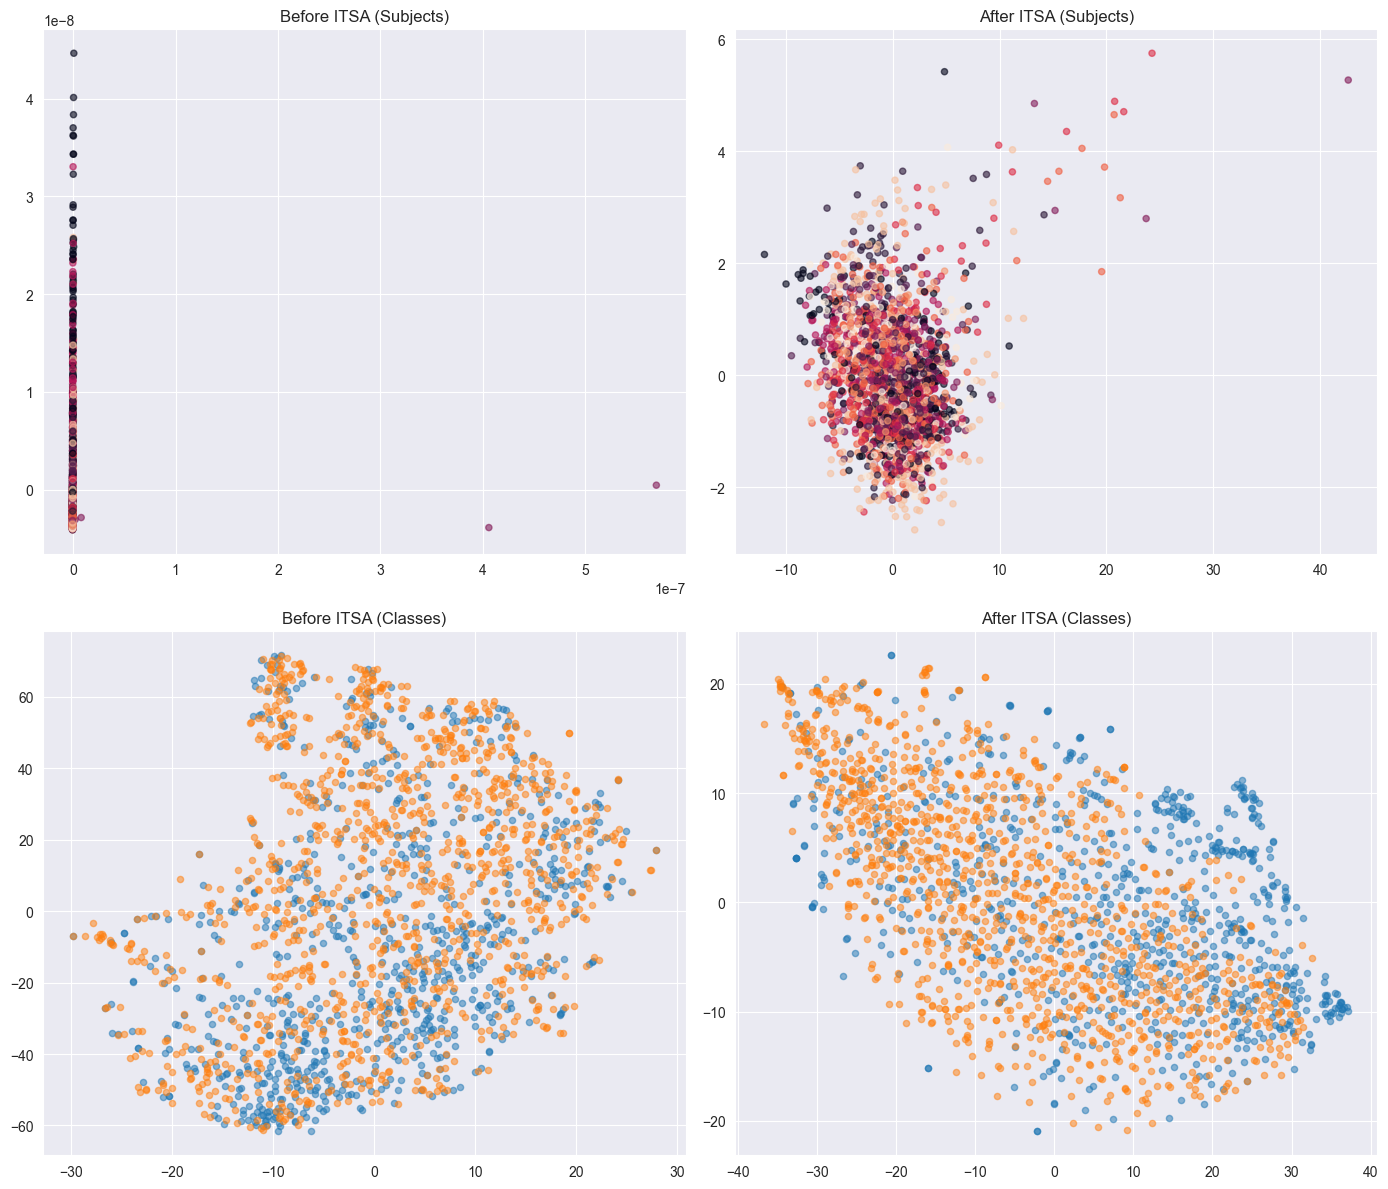


Within: 6.113963831637259e-09 → 9.163900009070392
Between: 7.544999788793806e-09 → 9.19014706156371
Ratio: 1.2340602588702803 → 1.0028641792760002


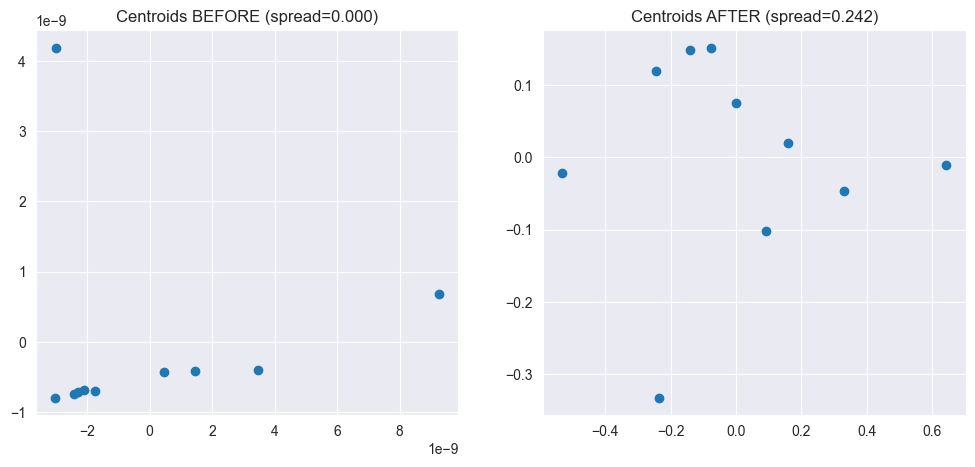

In [45]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import pairwise_distances

# ----------------------------------------
# flatten covariance (no recomputation)
# ----------------------------------------
def flatten_cov(C):
    n = C.shape[0]
    out = []
    for i in range(n):
        for j in range(i, n):
            if i == j:
                out.append(C[i, j])
            else:
                out.append(C[i, j] * np.sqrt(2))
    return np.array(out)

# ----------------------------------------
# sample
# ----------------------------------------
N_VIS = min(2000, len(X_ts))
idx = np.random.choice(len(X_ts), N_VIS, replace=False)

X_before = np.array([flatten_cov(covs[i]) for i in idx])
X_after  = X_ts[idx]

y_vis = y[idx]
subjects_vis = subjects[idx]

le = LabelEncoder()
subject_codes = le.fit_transform(subjects_vis)

# ----------------------------------------
# PCA
# ----------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

pca_b = PCA(n_components=2)
Xb = pca_b.fit_transform(X_before)

axes[0,0].scatter(Xb[:,0], Xb[:,1], c=subject_codes, alpha=0.6, s=20)
axes[0,0].set_title("Before ITSA (Subjects)")

pca_a = PCA(n_components=2)
Xa = pca_a.fit_transform(X_after)

axes[0,1].scatter(Xa[:,0], Xa[:,1], c=subject_codes, alpha=0.6, s=20)
axes[0,1].set_title("After ITSA (Subjects)")

# ----------------------------------------
# t-SNE
# ----------------------------------------
print("Running t-SNE...")

tsne_b = TSNE(n_components=2, perplexity=30, random_state=42)
Xb_tsne = tsne_b.fit_transform(X_before)

axes[1,0].scatter(Xb_tsne[y_vis==0,0], Xb_tsne[y_vis==0,1], alpha=0.5, s=20)
axes[1,0].scatter(Xb_tsne[y_vis==1,0], Xb_tsne[y_vis==1,1], alpha=0.5, s=20)
axes[1,0].set_title("Before ITSA (Classes)")

tsne_a = TSNE(n_components=2, perplexity=30, random_state=42)
Xa_tsne = tsne_a.fit_transform(X_after)

axes[1,1].scatter(Xa_tsne[y_vis==0,0], Xa_tsne[y_vis==0,1], alpha=0.5, s=20)
axes[1,1].scatter(Xa_tsne[y_vis==1,0], Xa_tsne[y_vis==1,1], alpha=0.5, s=20)
axes[1,1].set_title("After ITSA (Classes)")

plt.tight_layout()
plt.show()

# ----------------------------------------
# distance metrics
# ----------------------------------------
dist_b = pairwise_distances(X_before)
dist_a = pairwise_distances(X_after)

within_b, between_b = [], []
within_a, between_a = [], []

for i in range(N_VIS):
    for j in range(i+1, N_VIS):
        if subjects_vis[i] == subjects_vis[j]:
            within_b.append(dist_b[i,j])
            within_a.append(dist_a[i,j])
        else:
            between_b.append(dist_b[i,j])
            between_a.append(dist_a[i,j])

print("\nWithin:", np.mean(within_b), "→", np.mean(within_a))
print("Between:", np.mean(between_b), "→", np.mean(between_a))
print("Ratio:", (np.mean(between_b)/np.mean(within_b)),
                "→",
                (np.mean(between_a)/np.mean(within_a)))

# ----------------------------------------
# centroids
# ----------------------------------------
unique_subj = np.unique(subjects_vis)

centroids_b = []
centroids_a = []

for s in unique_subj:
    mask = subjects_vis == s
    if np.sum(mask) < 5:
        continue
    centroids_b.append(np.mean(X_before[mask], axis=0))
    centroids_a.append(np.mean(X_after[mask], axis=0))

centroids_b = np.array(centroids_b)
centroids_a = np.array(centroids_a)

cb = PCA(n_components=2).fit_transform(centroids_b)
ca = PCA(n_components=2).fit_transform(centroids_a)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(cb[:,0], cb[:,1])
plt.title(f"Centroids BEFORE (spread={np.std(cb):.3f})")

plt.subplot(1,2,2)
plt.scatter(ca[:,0], ca[:,1])
plt.title(f"Centroids AFTER (spread={np.std(ca):.3f})")

plt.show()

# both types, bigger window

In [25]:
import numpy as np
import mne

from scipy.signal import welch, coherence
from scipy.stats import entropy
from itertools import combinations
from scipy.linalg import fractional_matrix_power

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.covariance import LedoitWolf

from xgboost import XGBClassifier

from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace

# ============================================================
# CONFIG
# ============================================================

TARGET_SFREQ = 125
WINDOW_SEC = 1.0
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

FEATURE_SET = ["hjorth", "spectral", "bandpower", "coherence"]

# ============================================================
# SIGNAL LOADING
# ============================================================

def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        if np.any(np.std(data, axis=1) < 1e-10):
            return None, None

        return data, raw.ch_names
    except:
        return None, None

# ============================================================
# FEATURE FUNCTIONS (UNCHANGED)
# ============================================================

def hjorth_activity(x): return np.var(x)

def hjorth_mobility(x):
    if len(x) < 2: return np.nan
    v = np.var(x)
    if v == 0: return np.nan
    return np.sqrt(np.var(np.diff(x)) / v)

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    if np.isnan(m) or m == 0: return np.nan
    return hjorth_mobility(np.diff(x)) / m

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    return entropy(p)

def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

def extract_features_window(data, ch_names):
    feats = {}
    n_channels = len(ch_names)

    for i, ch in enumerate(ch_names):
        x = data[i]

        freqs, psd = welch(
            x,
            fs=TARGET_SFREQ,
            nperseg=WINDOW_LEN,
            noverlap=0
        )

        if "hjorth" in FEATURE_SET:
            a = hjorth_activity(x)
            m = hjorth_mobility(x)
            c = hjorth_complexity(x)

            feats[f"{ch}_a"] = a
            feats[f"{ch}_m"] = m
            feats[f"{ch}_c"] = c

        if "spectral" in FEATURE_SET:
            feats[f"{ch}_se"] = spectral_entropy(psd)

        if "bandpower" in FEATURE_SET:
            total = 0
            bp = {}

            for b, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs < high)
                val = np.trapezoid(psd[mask], freqs[mask]) if np.any(mask) else 0
                bp[b] = val
                total += val

            for b in bp:
                feats[f"{ch}_{b}"] = bp[b] / total if total > 0 else np.nan

    if "coherence" in FEATURE_SET:
        max_ch = min(8, n_channels)

        for i, j in combinations(range(max_ch), 2):
            freqs, coh = coherence(
                data[i], data[j],
                fs=TARGET_SFREQ,
                nperseg=WINDOW_LEN,
                noverlap=0
            )
            feats[f"coh_{i}_{j}"] = np.mean(coh)

    return feats

# ============================================================
# COVARIANCE (ITSA)
# ============================================================

def compute_covariance(w):
    # shrinkage covariance for stability
    return LedoitWolf().fit(w.T).covariance_

def whiten(C, C_ref):
    C_ref_inv_sqrt = fractional_matrix_power(C_ref, -0.5)
    return C_ref_inv_sqrt @ C @ C_ref_inv_sqrt

# ============================================================
# DATA BUILDING
# ============================================================

all_feats = []
all_covs = []
all_labels = []
all_subjects = []

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:

    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                continue

            for i in range(data.shape[1] // WINDOW_LEN):
                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                # handcrafted features
                feats = extract_features_window(w, ch_names)
                vals = np.array(list(feats.values()))
                if not np.all(np.isfinite(vals)):
                    continue

                # covariance
                C = compute_covariance(w)

                all_feats.append(vals)
                all_covs.append(C)
                all_labels.append(label)
                all_subjects.append(subj)

X_feats = np.array(all_feats)
covs = np.array(all_covs)
y = np.array(all_labels)
subjects = np.array(all_subjects)

# ============================================================
# SUBJECT SPLIT
# ============================================================

unique_subjects = np.unique(subjects)
np.random.seed(42)

train_subjects = np.random.choice(unique_subjects, int(0.7*len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

# ============================================================
# ITSA
# ============================================================

covs_train = covs[train_mask]
covs_test  = covs[test_mask]

subjects_train = subjects[train_mask]
subjects_test  = subjects[test_mask]

# ---- per-subject mean ----
C_ref = {}
for s in unique_subjects:
    idx = subjects == s
    C_ref[s] = mean_covariance(covs[idx], metric='riemann')

# ---- whitening ----
covs_white = []
for i in range(len(covs)):
    covs_white.append(whiten(covs[i], C_ref[subjects[i]]))
covs_white = np.array(covs_white)

covs_white_train = covs_white[train_mask]
covs_white_test  = covs_white[test_mask]

# ---- tangent space ----
ts = TangentSpace(metric='riemann')
ts.fit(covs_white_train)

X_ts_train = ts.transform(covs_white_train)
X_ts_test  = ts.transform(covs_white_test)

# ============================================================
# FINAL FEATURES
# ============================================================

X_train = np.concatenate([X_feats[train_mask], X_ts_train], axis=1)
X_test  = np.concatenate([X_feats[test_mask],  X_ts_test], axis=1)

y_train = y[train_mask]
y_test  = y[test_mask]

# ============================================================
# MODEL
# ============================================================

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.78      0.55      0.64      1800
           1       0.75      0.90      0.82      2700

    accuracy                           0.76      4500
   macro avg       0.77      0.72      0.73      4500
weighted avg       0.76      0.76      0.75      4500

ROC-AUC: 0.7912366255144033


# and another one

increase window to 1s, use only itsa features, per-band covariance, no coherency features

In [6]:
import numpy as np
from scipy.signal import butter, filtfilt
from scipy.linalg import fractional_matrix_power

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.covariance import LedoitWolf
from xgboost import XGBClassifier

from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace

In [7]:
TARGET_SFREQ = 125
WINDOW_SEC = 1.0
WINDOW_LEN = int(TARGET_SFREQ * WINDOW_SEC)

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

In [8]:
def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 45, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        if np.any(np.std(data, axis=1) < 1e-10):
            return None, None

        return data, raw.ch_names

    except:
        return None, None

## covariance and all other needed functions

In [16]:
# def bandpass(data, sfreq, low, high):
#     raw = mne.io.RawArray(data, mne.create_info(data.shape[0], sfreq, ch_types="eeg"))
#     raw.filter(low, high, verbose=False)
#     return raw.get_data()
def bandpass(data, sfreq, low, high, order=4):
    nyq = 0.5 * sfreq
    low = low / nyq
    high = high / nyq

    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, data, axis=1)

def compute_covariance(w, reg=1e-6):
    w = w - w.mean(axis=1, keepdims=True)

    C = np.cov(w)

    # diagonal loading (ensures SPD)
    C += reg * np.eye(C.shape[0])

    return C

def whiten(C, C_ref):
    C_ref_inv_sqrt = fractional_matrix_power(C_ref, -0.5)
    return C_ref_inv_sqrt @ C @ C_ref_inv_sqrt

## data building

In [17]:
X_covs = []
y_all = []
subjects_all = []

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:

    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:

        for f in file_list:

            data, ch_names = load_signal_all_channels(f)
            if data is None:
                continue

            total_len = data.shape[1]

            for i in range(total_len // WINDOW_LEN):

                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                if w.shape[1] < WINDOW_LEN:
                    continue

                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                band_covs = []

                for b, (low, high) in bands.items():

                    # SAFE filtering (no MNE)
                    w_b = bandpass(w, TARGET_SFREQ, low, high)

                    C = compute_covariance(w_b)
                    band_covs.append(C)

                X_covs.append(band_covs)
                y_all.append(label)
                subjects_all.append(subj)

y_all = np.array(y_all)
subjects_all = np.array(subjects_all)

## subject split

In [18]:
unique_subjects = np.unique(subjects_all)

np.random.seed(42)
train_subjects = np.random.choice(unique_subjects, int(0.7 * len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects_all, train_subjects)
test_mask = np.isin(subjects_all, test_subjects)

## ITSA pipeline

In [19]:
C_ref = {b: {} for b in bands}

for b_idx, b in enumerate(bands.keys()):
    for s in unique_subjects:

        idx = np.where(subjects_all == s)[0]

        covs_s = np.array([X_covs[i][b_idx] for i in idx])

        if covs_s.shape[0] > 0:
            C_ref[b][s] = mean_covariance(covs_s, metric="riemann")

## transform

In [20]:
X_train_list = []
X_test_list = []

for b_idx, b in enumerate(bands.keys()):

    covs_band = np.array([X_covs[i][b_idx] for i in range(len(X_covs))])

    covs_white = np.zeros_like(covs_band)

    for i in range(len(covs_band)):
        subj = subjects_all[i]
        covs_white[i] = whiten(covs_band[i], C_ref[b][subj])

    ts = TangentSpace(metric="riemann")
    ts.fit(covs_white[train_mask])

    X_train_list.append(ts.transform(covs_white[train_mask]))
    X_test_list.append(ts.transform(covs_white[test_mask]))

## final features

In [21]:
X_train = np.concatenate(X_train_list, axis=1)
X_test  = np.concatenate(X_test_list, axis=1)

y_train = y_all[train_mask]
y_test  = y_all[test_mask]

## model

In [23]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.63      0.42      0.50      1800
           1       0.68      0.84      0.75      2694

    accuracy                           0.67      4494
   macro avg       0.66      0.63      0.63      4494
weighted avg       0.66      0.67      0.65      4494

ROC-AUC: 0.7080777241606863


In [24]:
y_train.shape, y_test.shape

((10500,), (4494,))

# remove music task from train, use only music in test

## new rest and task files

In [26]:
import os
import glob
import random
import numpy as np
import mne
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.stats import entropy

DATA_DIR = "./data/ds004148"

subjects = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*")))

rest_files = {}
task_files = {}

for subj_path in subjects:
    subj = os.path.basename(subj_path)
    eeg_path = os.path.join(subj_path, "ses-session1", "eeg")

    # Rest: eyesclosed and eyesopen
    rest_closed = glob.glob(os.path.join(eeg_path, "*task-eyesclosed*_eeg.vhdr"))
    rest_open = glob.glob(os.path.join(eeg_path, "*task-eyesopen*_eeg.vhdr"))
    rest = rest_closed + rest_open

    # Task: everything that's NOT eyesclosed or eyesopen
    all_task = glob.glob(os.path.join(eeg_path, "*task-*_eeg.vhdr"))
    task = [t for t in all_task if "task-eyesclosed" not in t and "task-eyesopen" not in t]

    if len(rest) > 0:
        rest_files[subj] = rest  # Now rest is a list of files
    if len(task) > 0:
        task_files[subj] = task  # Or decide how to handle multiple tasks

subjects = sorted(rest_files.keys())

# Create train/test split (same split as before)
random.seed(42)  # For reproducibility
n_subjects = len(subjects)
n_test = 1  # Only putting sub-13 in test
test_subjects = [s for s in subjects if 'sub-13' in s]
train_subjects = [s for s in subjects if s not in test_subjects]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects: {test_subjects}")

# Organize files for train and test
train_rest = {}
train_task = {}
test_rest = {}
test_task = {}

# For test set: ONLY music files, no other active state types
for subj in test_subjects:
    if subj in rest_files:
        test_rest[subj] = rest_files[subj]

    # Filter task files to ONLY music files
    if subj in task_files:
        music_files = [f for f in task_files[subj] if "task-music" in f]
        # Ensure no other task types are included
        other_tasks = [f for f in task_files[subj] if "task-music" not in f]
        if other_tasks:
            print(f"Warning: Excluding non-music task files for {subj}: {other_tasks}")
        test_task[subj] = music_files

# For train set: keep all rest and all task files (including music and other tasks)
for subj in train_subjects:
    if subj in rest_files:
        train_rest[subj] = rest_files[subj]
    if subj in task_files:
        train_task[subj] = task_files[subj]  # Keep all task files

# Verify that test set only contains music files
print("\nTest set verification:")
for subj, files in test_task.items():
    print(f"{subj}: {len(files)} music files")
    for f in files:
        assert "task-music" in f, f"Non-music file found in test set: {f}"

# Verify no other active state types in test
print("\nTest set contains only music task files (no eyesclosed/eyesopen/music in test task)")
print(f"Test rest files (eyesclosed/eyesopen): {list(test_rest.keys()) if test_rest else 'None'}")
print(f"Test task files: {list(test_task.keys())}")

print(f"\nTrain set contains all rest files from {len(train_rest)} subjects")
print(f"Train set contains all task files from {len(train_task)} subjects")

Train subjects: ['sub-14', 'sub-15', 'sub-22', 'sub-23', 'sub-24', 'sub-25', 'sub-40', 'sub-47', 'sub-49']
Test subjects: ['sub-13']

Test set verification:
sub-13: 1 music files

Test set contains only music task files (no eyesclosed/eyesopen/music in test task)
Test rest files (eyesclosed/eyesopen): ['sub-13']
Test task files: ['sub-13']

Train set contains all rest files from 9 subjects
Train set contains all task files from 9 subjects


## now same model as the one that uses both features

In [27]:
import numpy as np
import mne

from scipy.signal import welch, coherence
from scipy.stats import entropy
from itertools import combinations
from scipy.linalg import fractional_matrix_power

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.covariance import LedoitWolf

from xgboost import XGBClassifier

from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace

# ============================================================
# CONFIG
# ============================================================

TARGET_SFREQ = 125
WINDOW_SEC = 1.0
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

FEATURE_SET = ["hjorth", "spectral", "bandpower", "coherence"]

# ============================================================
# SIGNAL LOADING
# ============================================================

def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        if np.any(np.std(data, axis=1) < 1e-10):
            return None, None

        return data, raw.ch_names
    except:
        return None, None

# ============================================================
# FEATURE FUNCTIONS (UNCHANGED)
# ============================================================

def hjorth_activity(x): return np.var(x)

def hjorth_mobility(x):
    if len(x) < 2: return np.nan
    v = np.var(x)
    if v == 0: return np.nan
    return np.sqrt(np.var(np.diff(x)) / v)

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    if np.isnan(m) or m == 0: return np.nan
    return hjorth_mobility(np.diff(x)) / m

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    return entropy(p)

def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

def extract_features_window(data, ch_names):
    feats = {}
    n_channels = len(ch_names)

    for i, ch in enumerate(ch_names):
        x = data[i]

        freqs, psd = welch(
            x,
            fs=TARGET_SFREQ,
            nperseg=WINDOW_LEN,
            noverlap=0
        )

        if "hjorth" in FEATURE_SET:
            a = hjorth_activity(x)
            m = hjorth_mobility(x)
            c = hjorth_complexity(x)

            feats[f"{ch}_a"] = a
            feats[f"{ch}_m"] = m
            feats[f"{ch}_c"] = c

        if "spectral" in FEATURE_SET:
            feats[f"{ch}_se"] = spectral_entropy(psd)

        if "bandpower" in FEATURE_SET:
            total = 0
            bp = {}

            for b, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs < high)
                val = np.trapezoid(psd[mask], freqs[mask]) if np.any(mask) else 0
                bp[b] = val
                total += val

            for b in bp:
                feats[f"{ch}_{b}"] = bp[b] / total if total > 0 else np.nan

    if "coherence" in FEATURE_SET:
        max_ch = min(8, n_channels)

        for i, j in combinations(range(max_ch), 2):
            freqs, coh = coherence(
                data[i], data[j],
                fs=TARGET_SFREQ,
                nperseg=WINDOW_LEN,
                noverlap=0
            )
            feats[f"coh_{i}_{j}"] = np.mean(coh)

    return feats

# ============================================================
# COVARIANCE (ITSA)
# ============================================================

def compute_covariance(w):
    # shrinkage covariance for stability
    return LedoitWolf().fit(w.T).covariance_

def whiten(C, C_ref):
    C_ref_inv_sqrt = fractional_matrix_power(C_ref, -0.5)
    return C_ref_inv_sqrt @ C @ C_ref_inv_sqrt

# ============================================================
# DATA BUILDING
# ============================================================

all_feats = []
all_covs = []
all_labels = []
all_subjects = []

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:

    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                continue

            for i in range(data.shape[1] // WINDOW_LEN):
                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                # handcrafted features
                feats = extract_features_window(w, ch_names)
                vals = np.array(list(feats.values()))
                if not np.all(np.isfinite(vals)):
                    continue

                # covariance
                C = compute_covariance(w)

                all_feats.append(vals)
                all_covs.append(C)
                all_labels.append(label)
                all_subjects.append(subj)

X_feats = np.array(all_feats)
covs = np.array(all_covs)
y = np.array(all_labels)
subjects = np.array(all_subjects)

# ============================================================
# SUBJECT SPLIT
# ============================================================

unique_subjects = np.unique(subjects)
np.random.seed(42)

train_subjects = np.random.choice(unique_subjects, int(0.7*len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

# ============================================================
# ITSA
# ============================================================

covs_train = covs[train_mask]
covs_test  = covs[test_mask]

subjects_train = subjects[train_mask]
subjects_test  = subjects[test_mask]

# ---- per-subject mean ----
C_ref = {}
for s in unique_subjects:
    idx = subjects == s
    C_ref[s] = mean_covariance(covs[idx], metric='riemann')

# ---- whitening ----
covs_white = []
for i in range(len(covs)):
    covs_white.append(whiten(covs[i], C_ref[subjects[i]]))
covs_white = np.array(covs_white)

covs_white_train = covs_white[train_mask]
covs_white_test  = covs_white[test_mask]

# ---- tangent space ----
ts = TangentSpace(metric='riemann')
ts.fit(covs_white_train)

X_ts_train = ts.transform(covs_white_train)
X_ts_test  = ts.transform(covs_white_test)

# ============================================================
# FINAL FEATURES
# ============================================================

X_train = np.concatenate([X_feats[train_mask], X_ts_train], axis=1)
X_test  = np.concatenate([X_feats[test_mask],  X_ts_test], axis=1)

y_train = y[train_mask]
y_test  = y[test_mask]

# ============================================================
# MODEL
# ============================================================

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.78      0.55      0.64      1800
           1       0.75      0.90      0.82      2700

    accuracy                           0.76      4500
   macro avg       0.77      0.72      0.73      4500
weighted avg       0.76      0.76      0.75      4500

ROC-AUC: 0.7912366255144033


# remove music from everywhere

In [28]:
import os
import glob
import random
import numpy as np
import mne
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.stats import entropy

DATA_DIR = "./data/ds004148"

subjects = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*")))

rest_files = {}
task_files = {}

for subj_path in subjects:
    subj = os.path.basename(subj_path)
    eeg_path = os.path.join(subj_path, "ses-session1", "eeg")

    # Rest: eyesclosed and eyesopen
    rest_closed = glob.glob(os.path.join(eeg_path, "*task-eyesclosed*_eeg.vhdr"))
    rest_open = glob.glob(os.path.join(eeg_path, "*task-eyesopen*_eeg.vhdr"))
    rest = rest_closed + rest_open

    # Task: everything that's NOT eyesclosed, eyesopen, OR music
    all_task = glob.glob(os.path.join(eeg_path, "*task-*_eeg.vhdr"))
    task = [t for t in all_task
            if "task-eyesclosed" not in t
            and "task-eyesopen" not in t
            and "task-music" not in t]  # Exclude music files

    if len(rest) > 0:
        rest_files[subj] = rest
    if len(task) > 0:
        task_files[subj] = task

subjects = sorted(rest_files.keys())
subjects

['sub-13',
 'sub-14',
 'sub-15',
 'sub-22',
 'sub-23',
 'sub-24',
 'sub-25',
 'sub-40',
 'sub-47',
 'sub-49']

In [29]:
import numpy as np
import mne

from scipy.signal import welch, coherence
from scipy.stats import entropy
from itertools import combinations
from scipy.linalg import fractional_matrix_power

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.covariance import LedoitWolf

from xgboost import XGBClassifier

from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace

# ============================================================
# CONFIG
# ============================================================

TARGET_SFREQ = 125
WINDOW_SEC = 1.0
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

FEATURE_SET = ["hjorth", "spectral", "bandpower", "coherence"]

# ============================================================
# SIGNAL LOADING
# ============================================================

def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        if np.any(np.std(data, axis=1) < 1e-10):
            return None, None

        return data, raw.ch_names
    except:
        return None, None

# ============================================================
# FEATURE FUNCTIONS (UNCHANGED)
# ============================================================

def hjorth_activity(x): return np.var(x)

def hjorth_mobility(x):
    if len(x) < 2: return np.nan
    v = np.var(x)
    if v == 0: return np.nan
    return np.sqrt(np.var(np.diff(x)) / v)

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    if np.isnan(m) or m == 0: return np.nan
    return hjorth_mobility(np.diff(x)) / m

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    return entropy(p)

def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

def extract_features_window(data, ch_names):
    feats = {}
    n_channels = len(ch_names)

    for i, ch in enumerate(ch_names):
        x = data[i]

        freqs, psd = welch(
            x,
            fs=TARGET_SFREQ,
            nperseg=WINDOW_LEN,
            noverlap=0
        )

        if "hjorth" in FEATURE_SET:
            a = hjorth_activity(x)
            m = hjorth_mobility(x)
            c = hjorth_complexity(x)

            feats[f"{ch}_a"] = a
            feats[f"{ch}_m"] = m
            feats[f"{ch}_c"] = c

        if "spectral" in FEATURE_SET:
            feats[f"{ch}_se"] = spectral_entropy(psd)

        if "bandpower" in FEATURE_SET:
            total = 0
            bp = {}

            for b, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs < high)
                val = np.trapezoid(psd[mask], freqs[mask]) if np.any(mask) else 0
                bp[b] = val
                total += val

            for b in bp:
                feats[f"{ch}_{b}"] = bp[b] / total if total > 0 else np.nan

    if "coherence" in FEATURE_SET:
        max_ch = min(8, n_channels)

        for i, j in combinations(range(max_ch), 2):
            freqs, coh = coherence(
                data[i], data[j],
                fs=TARGET_SFREQ,
                nperseg=WINDOW_LEN,
                noverlap=0
            )
            feats[f"coh_{i}_{j}"] = np.mean(coh)

    return feats

# ============================================================
# COVARIANCE (ITSA)
# ============================================================

def compute_covariance(w):
    # shrinkage covariance for stability
    return LedoitWolf().fit(w.T).covariance_

def whiten(C, C_ref):
    C_ref_inv_sqrt = fractional_matrix_power(C_ref, -0.5)
    return C_ref_inv_sqrt @ C @ C_ref_inv_sqrt

# ============================================================
# DATA BUILDING
# ============================================================

all_feats = []
all_covs = []
all_labels = []
all_subjects = []

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:

    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                continue

            for i in range(data.shape[1] // WINDOW_LEN):
                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                # handcrafted features
                feats = extract_features_window(w, ch_names)
                vals = np.array(list(feats.values()))
                if not np.all(np.isfinite(vals)):
                    continue

                # covariance
                C = compute_covariance(w)

                all_feats.append(vals)
                all_covs.append(C)
                all_labels.append(label)
                all_subjects.append(subj)

X_feats = np.array(all_feats)
covs = np.array(all_covs)
y = np.array(all_labels)
subjects = np.array(all_subjects)

# ============================================================
# SUBJECT SPLIT
# ============================================================

unique_subjects = np.unique(subjects)
np.random.seed(42)

train_subjects = np.random.choice(unique_subjects, int(0.7*len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

# ============================================================
# ITSA
# ============================================================

covs_train = covs[train_mask]
covs_test  = covs[test_mask]

subjects_train = subjects[train_mask]
subjects_test  = subjects[test_mask]

# ---- per-subject mean ----
C_ref = {}
for s in unique_subjects:
    idx = subjects == s
    C_ref[s] = mean_covariance(covs[idx], metric='riemann')

# ---- whitening ----
covs_white = []
for i in range(len(covs)):
    covs_white.append(whiten(covs[i], C_ref[subjects[i]]))
covs_white = np.array(covs_white)

covs_white_train = covs_white[train_mask]
covs_white_test  = covs_white[test_mask]

# ---- tangent space ----
ts = TangentSpace(metric='riemann')
ts.fit(covs_white_train)

X_ts_train = ts.transform(covs_white_train)
X_ts_test  = ts.transform(covs_white_test)

# ============================================================
# FINAL FEATURES
# ============================================================

X_train = np.concatenate([X_feats[train_mask], X_ts_train], axis=1)
X_test  = np.concatenate([X_feats[test_mask],  X_ts_test], axis=1)

y_train = y[train_mask]
y_test  = y[test_mask]

# ============================================================
# MODEL
# ============================================================

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.76      0.71      0.73      1800
           1       0.73      0.78      0.75      1800

    accuracy                           0.74      3600
   macro avg       0.74      0.74      0.74      3600
weighted avg       0.74      0.74      0.74      3600

ROC-AUC: 0.8129782407407409


## feature importances

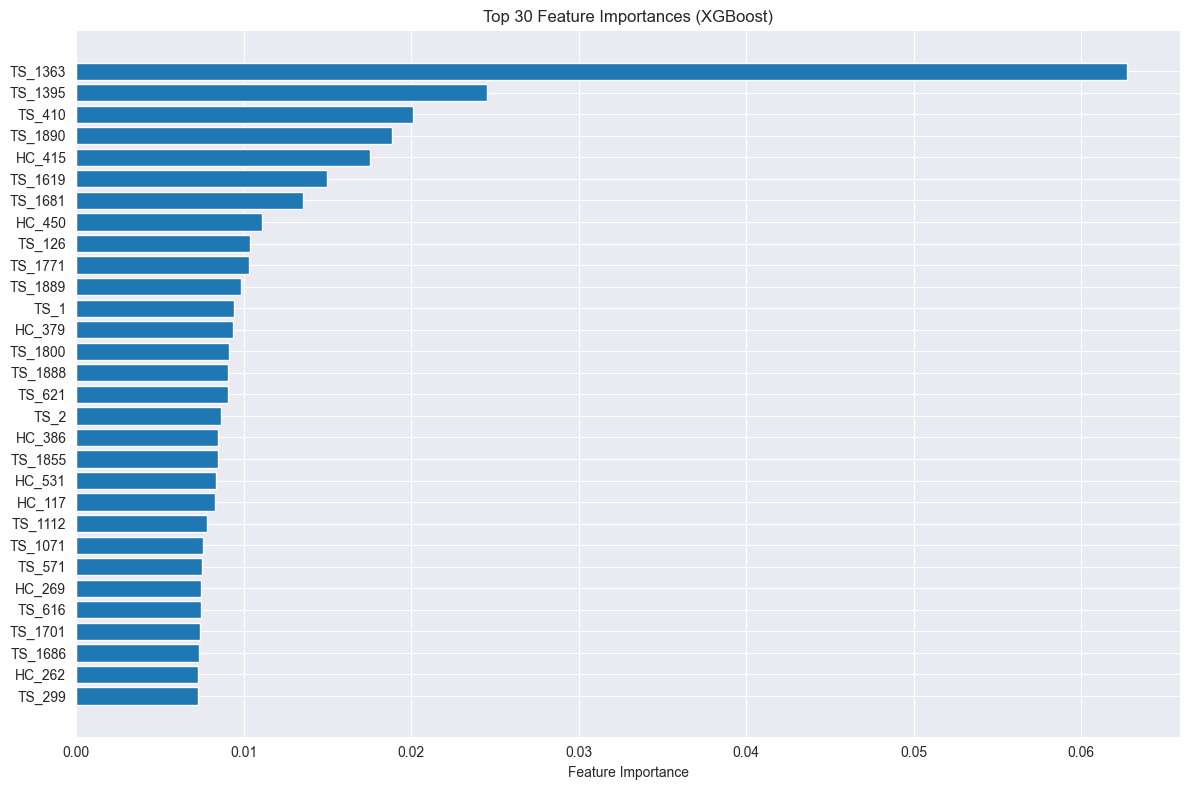

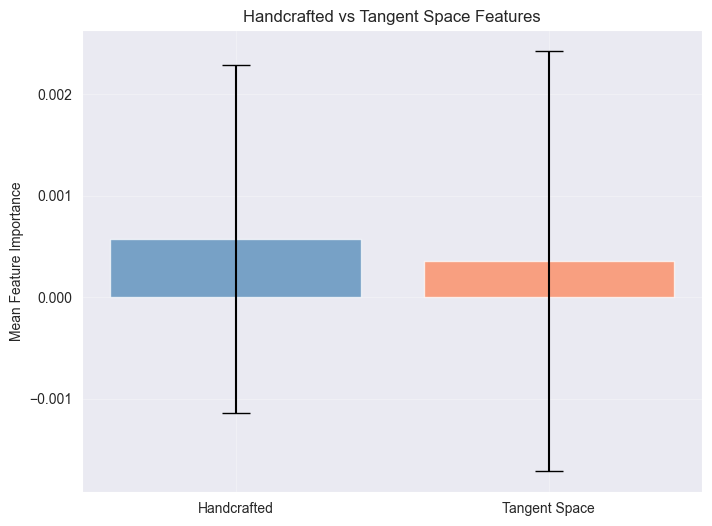


=== Feature Importance Summary ===
Total features: 2468
Handcrafted features: 577 (mean importance: 0.0006)
Tangent Space features: 1891 (mean importance: 0.0004)

Top 10 most important features:
  1. TS_1363: 0.062757
  2. TS_1395: 0.024528
  3. TS_410: 0.020115
  4. TS_1890: 0.018853
  5. HC_415: 0.017517
  6. TS_1619: 0.015005
  7. TS_1681: 0.013537
  8. HC_450: 0.011105
  9. TS_126: 0.010408
  10. TS_1771: 0.010348


In [30]:
# ============================================================
# FEATURE IMPORTANCES
# ============================================================

# Get feature importances from the model
feature_importance = model.feature_importances_

# Create feature names for handcrafted features
feature_names = []

# Get channel names from your data (assuming you have ch_names from earlier)
# You'll need to have ch_names available from your data loading step
# For this example, I'll create generic names
n_handcrafted = X_feats.shape[1]
feature_names.extend([f"HC_{i}" for i in range(n_handcrafted)])

# Add names for tangent space features
n_ts_features = X_ts_train.shape[1]
feature_names.extend([f"TS_{i}" for i in range(n_ts_features)])

# Sort features by importance
sorted_idx = np.argsort(feature_importance)[::-1]
sorted_importance = feature_importance[sorted_idx]
sorted_names = [feature_names[i] for i in sorted_idx]

# Plot top 30 features
plt.figure(figsize=(12, 8))
top_n = min(30, len(sorted_importance))
plt.barh(range(top_n), sorted_importance[:top_n][::-1])
plt.yticks(range(top_n), sorted_names[:top_n][::-1])
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

# Separate analysis: Handcrafted vs Tangent Space features
hc_importance = feature_importance[:n_handcrafted]
ts_importance = feature_importance[n_handcrafted:]

plt.figure(figsize=(8, 6))
categories = ['Handcrafted', 'Tangent Space']
means = [np.mean(hc_importance), np.mean(ts_importance)]
stds = [np.std(hc_importance), np.std(ts_importance)]

plt.bar(categories, means, yerr=stds, capsize=10, alpha=0.7,
        color=['steelblue', 'coral'])
plt.ylabel('Mean Feature Importance')
plt.title('Handcrafted vs Tangent Space Features')
plt.grid(True, alpha=0.3)
plt.show()

# Print summary statistics
print(f"\n=== Feature Importance Summary ===")
print(f"Total features: {len(feature_importance)}")
print(f"Handcrafted features: {n_handcrafted} (mean importance: {np.mean(hc_importance):.4f})")
print(f"Tangent Space features: {n_ts_features} (mean importance: {np.mean(ts_importance):.4f})")
print(f"\nTop 10 most important features:")
for i in range(min(10, len(sorted_importance))):
    print(f"  {i+1}. {sorted_names[i]}: {sorted_importance[i]:.6f}")

# remove feature leakage lol

In [32]:
import os
import glob
import random
import numpy as np
import mne
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.stats import entropy

DATA_DIR = "./data/ds004148"

subjects = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*")))

rest_files = {}
task_files = {}

for subj_path in subjects:
    subj = os.path.basename(subj_path)
    eeg_path = os.path.join(subj_path, "ses-session1", "eeg")

    # Rest: eyesclosed and eyesopen
    rest_closed = glob.glob(os.path.join(eeg_path, "*task-eyesclosed*_eeg.vhdr"))
    rest_open = glob.glob(os.path.join(eeg_path, "*task-eyesopen*_eeg.vhdr"))
    rest = rest_closed + rest_open

    # Task: everything that's NOT eyesclosed, eyesopen, OR music
    all_task = glob.glob(os.path.join(eeg_path, "*task-*_eeg.vhdr"))
    task = [t for t in all_task
            if "task-eyesclosed" not in t
            and "task-eyesopen" not in t
            # and "task-music" not in t
            ]  # Exclude music files

    if len(rest) > 0:
        rest_files[subj] = rest
    if len(task) > 0:
        task_files[subj] = task

subjects = sorted(rest_files.keys())
subjects

['sub-13',
 'sub-14',
 'sub-15',
 'sub-22',
 'sub-23',
 'sub-24',
 'sub-25',
 'sub-40',
 'sub-47',
 'sub-49']

## 1 sec

In [36]:
import numpy as np
import mne

from scipy.signal import welch, coherence
from scipy.stats import entropy
from itertools import combinations
from scipy.linalg import fractional_matrix_power

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.covariance import LedoitWolf

from xgboost import XGBClassifier

from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace

# ============================================================
# CONFIG
# ============================================================

TARGET_SFREQ = 125
WINDOW_SEC = 1.0
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

FEATURE_SET = ["hjorth", "spectral", "bandpower", "coherence"]

# ============================================================
# SIGNAL LOADING
# ============================================================

def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        if np.any(np.std(data, axis=1) < 1e-10):
            return None, None

        return data, raw.ch_names
    except:
        return None, None

# ============================================================
# FEATURE FUNCTIONS (UNCHANGED)
# ============================================================

def hjorth_activity(x): return np.var(x)

def hjorth_mobility(x):
    if len(x) < 2: return np.nan
    v = np.var(x)
    if v == 0: return np.nan
    return np.sqrt(np.var(np.diff(x)) / v)

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    if np.isnan(m) or m == 0: return np.nan
    return hjorth_mobility(np.diff(x)) / m

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    return entropy(p)

def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

def extract_features_window(data, ch_names):
    feats = {}
    n_channels = len(ch_names)

    for i, ch in enumerate(ch_names):
        x = data[i]

        freqs, psd = welch(
            x,
            fs=TARGET_SFREQ,
            nperseg=WINDOW_LEN,
            noverlap=0
        )

        if "hjorth" in FEATURE_SET:
            a = hjorth_activity(x)
            m = hjorth_mobility(x)
            c = hjorth_complexity(x)

            feats[f"{ch}_a"] = a
            feats[f"{ch}_m"] = m
            feats[f"{ch}_c"] = c

        if "spectral" in FEATURE_SET:
            feats[f"{ch}_se"] = spectral_entropy(psd)

        if "bandpower" in FEATURE_SET:
            total = 0
            bp = {}

            for b, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs < high)
                val = np.trapezoid(psd[mask], freqs[mask]) if np.any(mask) else 0
                bp[b] = val
                total += val

            for b in bp:
                feats[f"{ch}_{b}"] = bp[b] / total if total > 0 else np.nan

    if "coherence" in FEATURE_SET:
        max_ch = min(8, n_channels)

        for i, j in combinations(range(max_ch), 2):
            freqs, coh = coherence(
                data[i], data[j],
                fs=TARGET_SFREQ,
                nperseg=WINDOW_LEN,
                noverlap=0
            )
            feats[f"coh_{i}_{j}"] = np.mean(coh)

    return feats

# ============================================================
# COVARIANCE (ITSA)
# ============================================================

def compute_covariance(w):
    # shrinkage covariance for stability
    return LedoitWolf().fit(w.T).covariance_

def whiten(C, C_ref):
    C_ref_inv_sqrt = fractional_matrix_power(C_ref, -0.5)
    return C_ref_inv_sqrt @ C @ C_ref_inv_sqrt

# ============================================================
# DATA BUILDING
# ============================================================

all_feats = []
all_covs = []
all_labels = []
all_subjects = []

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:

    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                continue

            for i in range(data.shape[1] // WINDOW_LEN):
                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                # handcrafted features
                feats = extract_features_window(w, ch_names)
                vals = np.array(list(feats.values()))
                if not np.all(np.isfinite(vals)):
                    continue

                # covariance
                C = compute_covariance(w)

                all_feats.append(vals)
                all_covs.append(C)
                all_labels.append(label)
                all_subjects.append(subj)

X_feats = np.array(all_feats)
covs = np.array(all_covs)
y = np.array(all_labels)
subjects = np.array(all_subjects)

# ============================================================
# SUBJECT SPLIT
# ============================================================

unique_subjects = np.unique(subjects)
np.random.seed(42)

train_subjects = np.random.choice(unique_subjects, int(0.7*len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

# ============================================================
# ITSA (LEAKAGE FIXED)
# ============================================================

covs_train = covs[train_mask]
covs_test  = covs[test_mask]

# ---- compute global reference from TRAIN only ----
global_ref = mean_covariance(covs_train, metric='riemann')

covs_white_train = np.array([
    whiten(C, global_ref) for C in covs_train
])

covs_white_test = np.array([
    whiten(C, global_ref) for C in covs_test
])

# ---- tangent space projection ----
ts = TangentSpace(metric='riemann')
ts.fit(covs_white_train)

X_ts_train = ts.transform(covs_white_train)
X_ts_test  = ts.transform(covs_white_test)

# ============================================================
# FINAL FEATURES (OPTIONAL: normalize handcrafted features)
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_feats_train = scaler.fit_transform(X_feats[train_mask])
X_feats_test  = scaler.transform(X_feats[test_mask])

# ---- concatenate features ----
X_train = np.concatenate([X_feats_train, X_ts_train], axis=1)
X_test  = np.concatenate([X_feats_test,  X_ts_test], axis=1)

y_train = y[train_mask]
y_test  = y[test_mask]

# ============================================================
# FINAL FEATURES
# ============================================================

# X_train = np.concatenate([X_feats[train_mask], X_ts_train], axis=1)
# X_test  = np.concatenate([X_feats[test_mask],  X_ts_test], axis=1)
#
# y_train = y[train_mask]
# y_test  = y[test_mask]

# ============================================================
# MODEL
# ============================================================

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.74      0.28      0.41      1800
           1       0.66      0.93      0.77      2700

    accuracy                           0.67      4500
   macro avg       0.70      0.61      0.59      4500
weighted avg       0.69      0.67      0.63      4500

ROC-AUC: 0.6888521604938271
